In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import interpolate
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
#this next line is only needed in iPython notebooks
%matplotlib inline 
from scipy.interpolate import BPoly
import math
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick
font = fm.FontProperties(family = 'Gill Sans', fname = '/Library/Fonts/GillSans.ttc', size = 20)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
def hide_spines(intx=False,inty=False):
    """Hides the top and rightmost axis spines from view for all active
    figures and their respective axes."""

    # Retrieve a list of all current figures.
    figures = [x for x in matplotlib._pylab_helpers.Gcf.get_all_fig_managers()]
    if (plt.gca().get_legend()):
        plt.setp(plt.gca().get_legend().get_texts(), fontproperties=font) 
    for figure in figures:
        # Get all Axis instances related to the figure.
        for ax in figure.canvas.figure.get_axes():
            # Disable spines.
            ax.spines['right'].set_color('none')
            ax.spines['top'].set_color('none')
            # Disable ticks.
            ax.xaxis.set_ticks_position('bottom')
            ax.yaxis.set_ticks_position('left')
           # ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: ("10$^{%d}$" % math.log(v,10)) ))
            for label in ax.get_xticklabels() :
                label.set_fontproperties(font)
            for label in ax.get_yticklabels() :
                label.set_fontproperties(font)
            #ax.set_xticklabels(ax.get_xticks(), fontproperties = font)
            ax.set_xlabel(ax.get_xlabel(), fontproperties = font)
            ax.set_ylabel(ax.get_ylabel(), fontproperties = font)
            ax.set_title(ax.get_title(), fontproperties = font)
            if (inty):
                ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%d'))
            if (intx):
                ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d'))
def show(nm,a=0,b=0):
    hide_spines(a,b)
    #ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: ("10$^{%d}$" % math.log(v,10)) ))
    #plt.yticks([1,1e-2,1e-4,1e-6,1e-8,1e-10,1e-12], labels)
    #ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: ("10$^{%d}$" % math.log(v,10)) ))
    if (len(nm)>0):
        plt.savefig(nm+".pdf",bbox_inches='tight');
    plt.show()
    
    

c = 300.0 # speed of light
a = 0.01372 #radiation constant
ac = a*c
%matplotlib inline

In [2]:
import numpy as np
import math
from tabulate import tabulate
from scipy.sparse.linalg import LinearOperator
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
def sweep1D_bern1(I,hx,q,sigma_t,mu,boundary):
    """Compute a transport sweep for a given
    Inputs:
        I:               number of zones 
        hx:              size of each zone
        q:               source array
        sigma_t:         array of total cross-sections
        mu:              direction to sweep
        boundary:        value of angular flux on the boundary
    Outputs:
        psi:             value of angular flux in each zone
    """
    
    
    psi = np.zeros((I,2))
    ihx = 1/hx
    h = hx
    M = np.array([[1./9,1./18],[1./18,4./63]])*h
    K = np.array([[-0.5,-0.5],[0.5,0.5]])
    if (mu > 0): 
        psi_left = boundary
        for i in range(I):
            iminhalf = np.array([0,1])
            iplushalf = np.array([0,1])
            rhs = np.dot(M,q[i,:]) + mu*np.dot(np.array([[0,1],[0,0]]),psi_left)
            lhs = M*sigma_t[i] - mu*K + np.diag(iplushalf)*mu
            tmp = np.linalg.solve(lhs,rhs)
            psi[i,:] = tmp.reshape(2) 
            psi_left = tmp
    else:
        psi_right = boundary
        iminhalf = np.array([1,0])
        iplushalf = np.array([1,0])
        for i in reversed(range(I)):
            rhs =  - mu*np.dot(np.array([[0,0],[1,0]]),psi_right) + np.dot(M,q[i,:])
            lhs = M*sigma_t[i] - mu*K - np.diag(iminhalf)*mu
            tmp = np.linalg.solve(lhs,rhs)
            #print(rhs,lhs,tmp)
            psi[i,:] = tmp.reshape(2)
            psi_right = tmp
    return psi

In [3]:
from numba import jit, int32, float64
@jit(float64[:,:](int32,float64,float64[:,:],float64[:,:],float64, float64[:],int32,int32), nopython=True)
def sweep1D_bern(I,hx,q,sigma_t,mu,boundary,order=1,fix=0):
    """Compute a transport sweep for a given
    Inputs:
        I:               number of zones 
        hx:              size of each zone
        q:               source array
        sigma_t:         array of total cross-sections
        mu:              direction to sweep
        boundary:        value of angular flux on the boundary
    Outputs:
        psi:             value of angular flux in each zone
    """
    
    lumped = 1
    psi = np.zeros((I,order+1))
    ihx = 1/hx
    h = hx
    if (order==1):
        M = np.array([[0.333333, 0.166667],[0.166667, 0.333333]])*h
        K = np.array([[-0.5,-0.5],[0.5,0.5]])
    elif (order == 2):
        M = np.array([[0.2, 0.1, 0.0333333], 
                      [0.1, 0.133333, 0.1], 
                      [0.0333333, 0.1, 0.2]])*h
        K = np.array([[-0.5, -0.333333, -0.166667], 
                      [0.333333, 0., -0.333333], 
                      [0.166667, 0.333333, 0.5]])
    
    elif (order == 3):
        M = np.array([[0.142857, 0.0714286, 0.0285714, 0.00714286], 
                      [0.0714286, 0.0857143,   0.0642857, 0.0285714], 
                      [0.0285714, 0.0642857, 0.0857143,   0.0714286], 
                      [0.00714286, 0.0285714, 0.0714286, 0.142857]])*h
        K = np.array([[-0.5, -0.3, -0.15, -0.05], [0.3, 0., -0.15, -0.15], [0.15, 0.15, 0., -0.3], [0.05, 0.15, 0.3, 0.5]])
    elif (order == 4):
        M = np.array([[0.111111, 0.0555556, 0.0238095, 0.00793651, 0.0015873],
                     [0.0555556, 0.0634921, 0.047619, 0.0253968, 0.00793651],
                     [0.0238095, 0.047619, 0.0571429, 0.047619, 0.0238095],
                     [0.00793651, 0.0253968, 0.047619, 0.0634921, 0.0555556],
                     [0.0015873, 0.00793651, 0.0238095, 0.0555556, 0.111111]])*h
        K = np.array([[-0.5, -0.285714, -0.142857, -0.0571429, -0.0142857], 
                      [0.285714, 0., -0.114286, -0.114286, -0.0571429],
                      [0.142857, 0.114286, 0., -0.114286, -0.142857],
                      [0.0571429, 0.114286, 0.114286, 0., -0.285714],
                      [0.0142857, 0.0571429, 0.142857, 0.285714, 0.5]])
    elif (order == 5):
        M = np.array([[0.0909091, 0.0454545, 0.020202, 0.00757576, 0.0021645, 0.00036075],
                     [0.0454545, 0.0505051, 0.0378788, 0.021645, 0.00901876, 0.0021645],
                     [0.020202, 0.0378788, 0.04329, 0.036075, 0.021645, 0.00757576],
                     [0.00757576, 0.021645, 0.036075, 0.04329, 0.0378788, 0.020202],
                     [0.0021645, 0.00901876, 0.021645, 0.0378788, 0.0505051, 0.0454545],
                     [0.00036075, 0.0021645, 0.00757576, 0.020202, 0.0454545, 0.0909091]])*h
        K = np.array([[-0.5, -0.277778, -0.138889, -0.0595238, -0.0198413, -0.00396825], 
                      [0.277778, 0., -0.0992063, -0.0992063, -0.0595238, -0.0198413],
                      [0.138889, 0.0992063, 0., -0.0793651, -0.0992063, -0.0595238],
                      [0.0595238, 0.0992063, 0.0793651, 0., -0.0992063, -0.138889],
                      [0.0198413, 0.0595238, 0.0992063, 0.0992063, 0., -0.277778],
                      [0.00396825, 0.0198413, 0.0595238, 0.138889, 0.277778, 0.5]])
    elif (order == 6):
        M = np.array([[0.0769231, 0.0384615, 0.0174825, 0.00699301, 0.002331, 0.000582751,   0.0000832501], 
                      [0.0384615, 0.041958, 0.0314685, 0.018648,   0.00874126, 0.002997, 0.000582751], 
                      [0.0174825, 0.0314685, 0.034965,   0.0291375, 0.0187313, 0.00874126, 0.002331], 
                      [0.00699301, 0.018648,   0.0291375, 0.0333, 0.0291375, 0.018648, 0.00699301], 
                      [0.002331,   0.00874126, 0.0187313, 0.0291375, 0.034965, 0.0314685,   0.0174825], 
                      [0.000582751, 0.002997, 0.00874126, 0.018648, 0.0314685,   0.041958, 0.0384615], 
                      [0.0000832501, 0.000582751, 0.002331,   0.00699301, 0.0174825, 0.0384615, 0.0769231]])*h
        K = np.array([[-0.5, -0.272727, -0.136364, -0.0606061, -0.0227273, -0.00649351,-0.00108225],
                      [0.272727,   0., -0.0909091, -0.0909091, -0.0584416, -0.025974, -0.00649351],
                      [0.136364, 0.0909091,   0., -0.0649351, -0.0811688, -0.0584416, -0.0227273], 
                      [0.0606061,   0.0909091, 0.0649351,   0., -0.0649351, -0.0909091, -0.0606061], 
                      [0.0227273, 0.0584416,   0.0811688, 0.0649351, 0., -0.0909091, -0.136364], 
                      [0.00649351,   0.025974, 0.0584416, 0.0909091, 0.0909091,   0., -0.272727], 
                      [0.00108225, 0.00649351, 0.0227273, 0.0606061, 0.136364, 0.272727, 0.5]])
    if ( lumped > 0):
        M_new = M*0
        K_new = K*0
        for i in range(order+1):
            M_new[i,i] = np.sum(M[i,:])
            K_new[i,i] = np.sum(K[i,:])
        M = M_new
        #K = K_new
    if (mu > 0): 
        psi_left = boundary
        for i in range(I):
            if (order == 4):
                iminhalf = np.array([0,0,0,0,1.0])
                iplushalf = np.array([0,0,0,0,1.0])
            elif (order == 1):
                iminhalf = np.array([0,1.])
                iplushalf = np.array([0,1.])
            else:
                iminhalf = np.zeros(order+1)
                iminhalf[-1] = 1
                iplushalf = np.zeros(order+1)
                iplushalf[-1] = 1
                      
            rhs = np.dot(M,q[i,:]) 
            rhs[0] += mu*psi_left[-1] 
            lhs = M*np.diag(sigma_t[i]) - mu*K + np.diag(iplushalf)*mu
            tmp = np.linalg.solve(lhs,rhs)
            if (fix >0) and (np.min(tmp)<0):
                tmpZ = (tmp>0)*tmp
                tmp = tmpZ*(np.sum(rhs)/(np.sum(np.dot(lhs,tmpZ))+1e-14))
            psi[i,:] = tmp.reshape(order+1) 
            psi_left = tmp
    else:
        psi_right = boundary
        for i in range(I):
            if (order == 4):
                iminhalf = np.array([1.0,0,0,0,0])
                iplushalf = np.array([1.0,0,0,0,0,0])
            elif (order == 1):
                iminhalf = np.array([1.0,0])
                iplushalf = np.array([1.0,0])
            else:
                iminhalf = np.zeros(order+1)
                iminhalf[0] = 1
                iplushalf = np.zeros(order+1)
                iplushalf[0] = 1
        #iminhalf = np.array([1,0])
        #iplushalf = np.array([1,0])
        for i in range(I-1,-1,-1):
            rhs =   np.dot(M,q[i,:])
            rhs[-1] += - mu*psi_right[0]
            lhs = M*np.diag(sigma_t[i]) - mu*K - np.diag(iminhalf)*mu
            tmp = np.linalg.solve(lhs,rhs)
            #print(lhs,rhs,tmp)
            if (fix >0) and (np.min(tmp)<0):
                tmpZ = (tmp>0)*tmp
                tmp = tmpZ*(np.sum(rhs)/(np.sum(np.dot(lhs,tmpZ))+1e-14))
            psi[i,:] = tmp.reshape(order+1)
            psi_right = tmp
    return psi

/var/folders/68/pdkq9t_j2gd7ksjtnf73t0vw0000gp/T/ipykernel_71772/1414401641.py:99: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (array(float64, 2d, C), array(float64, 1d, A))
  rhs = np.dot(M,q[i,:])
/var/folders/68/pdkq9t_j2gd7ksjtnf73t0vw0000gp/T/ipykernel_71772/1414401641.py:99: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (array(float64, 2d, C), array(float64, 1d, A))
  rhs = np.dot(M,q[i,:])


In [4]:
def source_iteration(I,hx,q,sigma_t,sigma_s,N,BCs, phi=np.zeros(1),
                     Linf_tol = 1.0e-5, tolerance = 1.0e-8,maxits = 100, 
                     LOUD=False, plot = False, DSA=False, order=4, fix=0 ):
    """Perform source iteration for single-group steady state problem
    Inputs:
        I:               number of zones 
        hx:              size of each zone
        q:               source array
        sigma_t:         array of total cross-sections
        sigma_s:         array of scattering cross-sections
        N:               number of angles
        tolerance:       the relative convergence tolerance for the iterations
        maxits:          the maximum number of iterations
        LOUD:            boolean to print out iteration stats
    Outputs:
        x:               value of center of each zone
        phi:             value of scalar flux in each zone
    """
    if (phi.size != I*(order+1)):
        phi = np.zeros((I,order+1))
    phi_old = phi.copy()
    converged = False
    MU, W = np.polynomial.legendre.leggauss(N)
    W /= np.sum(W)
    psi = np.zeros((I,N,order+1))
    psi[0,:,:] = phi[0,:]/np.sum(W)
    psi[-1,:,:] = phi[-1,:]/np.sum(W)
    iteration = 1
    if plot:
        plotvar = np.zeros(1)
        plotvar[0] = np.mean(phi_old)
    while not(converged):
        phi = np.zeros((I,order+1))
        #sweep over each direction
        for n in range(N):
            #deal with reflecting BC
            if ((BCs[n,0] < 0) and (n>=N//2)):
                tmpBC = psi[-1,n-N//2,:]
            elif ((BCs[n,0] < 0) and (n<N//2)):
                tmpBC = psi[0,n+N//2,:]
            else:
                tmpBC = BCs[n,:]
            source = q.copy()
            for node in range(order+1):
                source[:,n,node] += phi_old[:,node]*sigma_s[:,node] 
            tmp_psi = sweep1D_bern(I,hx,np.array(source[:,n,:]),np.array(sigma_t),MU[n],tmpBC,order=order,fix=fix)
            psi[:,n,:] = tmp_psi.copy()
            phi += tmp_psi*W[n]
        if plot:
            plotvar = np.append(plotvar,np.mean(phi))
        #check convergence
        
        L2err = np.sum((phi_old.reshape(I*(order+1))/phi.reshape(I*(order+1))  - 1)**2/math.sqrt(I))
        if (iteration != 1):
            change = np.append(change,L2err)
        else:
            change = np.zeros(1)+L2err
        Linferr = np.max(np.abs(phi_old/phi-1))
        converged = ((L2err < tolerance) and (Linferr < Linf_tol)) or (iteration > maxits)
        if (LOUD>0) or (converged and LOUD<0):
            print("Iteration",iteration,": Relative Change =",L2err,Linferr)
        if (iteration > maxits) and ( not(DSA)):
            print("Warning: Source Iteration did not converge")
        iteration += 1
        phi_old = phi.copy()
    x = np.linspace(hx/2,I*hx-hx/2,I)
    if DSA:
        return x, phi, psi, iteration-1
    if plot:
        return x,phi,iteration-1,plotvar
    
                
                
        
    return x, phi, iteration-1,change

In [5]:
def temp_solve(I,hx,q,sigma_func,N,BCs, Cv, phi,psi, T,
               dt_val = 0.001, tfinal = 1.0,
                     Linf_tol = 1.0e-5, tolerance = 1.0e-8,maxits = 1000, 
                     LOUD=False, plot = False,order=4, fix=0 ):
    t_current = 0.0
    c = 300.0 # speed of light
    a = 0.01372 #radiation constant
    ac = a*c
    phis = []
    Ts = []
    phi_old = phi.copy()
    print(psi.shape)
    psi_old = psi.copy()
    T_old = T.copy()
    phis.append(phi_old)
    Ts.append(T_old)
    print("|", end = '')
    curr_step = 0
    iterations = 0
    while (t_current < tfinal):
        dt = np.min([dt_val,tfinal-t_current])
        t_current += dt
        if (int(10*t_current/tfinal) > curr_step):
            curr_step += 1
            print(curr_step, end = '')
        icdt = 1.0/(c*dt)
        beta = 4*a*T_old**3/Cv
        sigma = sigma_func(T_old)
        f = 1.0/(1+beta*c*dt*sigma)
        sigma_a = f*sigma
        sigma_s = (1-f)*sigma
        source = q + (sigma_a*ac*T_old**4)[:,None,:] + icdt*psi_old 
        sigma_t = sigma+icdt
        """print("f = ",f)
        print("sigma_t = ",sigma_t)
        print("sigma_s = ",sigma_s)
        print("source = ",source)
        """
        x, phi, psi, iteration = source_iteration(I,hx,source,sigma_t,sigma_s,N,BCs, phi=phi_old,
                     Linf_tol = Linf_tol, tolerance = tolerance,maxits = maxits, 
                     LOUD=LOUD, plot = plot, DSA=True, order=order, fix=fix )
        iterations += iteration
        T = T_old + sigma_a*dt*(phi-ac*T_old**4)/Cv
        #print(T)
        T_old = T.copy()
        phi_old = phi.copy()
        psi_old = psi.copy()
        phis.append(phi_old)
        Ts.append(T_old)
    return x, phis, Ts, iterations

In [6]:
def DMD_prec(matvec, b, K = 10, steady = 0, x = np.zeros(1), step_size = 10, GM = 0, res=1):
    res = np.min([1.0e-6,res])
    res = np.max([res,1e-11])
    #print(res)
    N = b.size
    linf = 0
    if x.size != b.size:
        x = b.copy()
    assert len(b.shape) == 1
    x_new = x*0
    x_orig = x.copy()
    x_0 = x.copy()
    #perform K iterations of matvec
    Yplus = np.zeros((N,K-1))
    Yminus = np.zeros((N,K-1))
    
    for k in range(K):
        x_new = matvec(x) + b 
        L2err = np.sum((x/x_new  - 1)**2/math.sqrt(N))
        Linferr = np.max(np.abs(x/x_new-1))
        if (k == 0):
            change = np.zeros(1) + L2err
            change_linf= np.zeros(1) + Linferr
        else:
            change = np.append(change,L2err)
            change_linf = np.append(change,Linferr)
        if (k < K-1):
            Yminus[:,k] = x_new - x
            
            x_0 = x_new.copy()
        if (k>0):
            Yplus[:,k-1] = x_new-x
        
        x = x_new.copy()
    #now perform update
    
    #compute svd
    [u,s,v] = np.linalg.svd(Yminus,full_matrices=False)
    #print("U shape =", u.shape, "V shape =", v.shape)
    #find the non-zero singular values
    if (x.size > 1) and (s[(1-np.cumsum(s)/np.sum(s)) > (1.e-3)*res].size >= 1):
        spos = s[(1-np.cumsum(s)/np.sum(s)) > (1.e-3)*res].copy()
    else:
        spos = s[s>0].copy()
    #create diagonal matrix
    mat_size = np.min([K,len(spos)])
    S = np.zeros((mat_size,mat_size))
    #select the u and v that correspond with the nonzero singular values
    unew = 1.0*u[:,0:mat_size]
    vnew = 1.0*v[0:mat_size,:]
    #S will be the inverse of the singular value diagonal matrix 
    S[np.diag_indices(mat_size)] = 1/spos
    #not sure we need this
    En = u.copy() 

    #the approximate A operator is Ut A U = Ut Y+ V S
    part1 = np.dot(np.matrix(unew).getH(),Yplus)
    part2 = np.dot(part1,np.matrix(vnew).getH())
    Atilde = np.dot(part2,np.matrix(S).getH())
    if (Atilde.shape[0] > 0):
        try:
            [eigsN,vsN] = np.linalg.eig(Atilde)
            if (np.max(np.abs(eigsN))>1):
                #an eigenvalue is too big
                print("*****Warning*****  The number of steps may be too small")
                eigsN[np.abs(eigsN) > 1] = 0
            eigsN = np.real(eigsN)
            #change Atilde to only have the right eigenvalues
            Atilde = np.real(np.dot(np.dot(vsN,np.diag(eigsN)),np.linalg.inv(vsN)))

            if steady:
                Z = np.dot(unew,vsN)
                Zdagger = np.linalg.solve(np.dot(Z.getH(),Z),Z.getH())
                rhs = np.dot(np.matrix(unew).getH(),Yplus[:,-1])
                delta_y = np.linalg.solve(np.identity(Atilde.shape[0]) - Atilde,np.transpose(rhs))
                x_old = - (Yplus[:,K-1-1] - x)
                steady_update = x_old + np.transpose(np.dot(unew,delta_y))
                return steady_update, change, change_linf, Atilde,Yplus,Yminus
            else:

                Z = np.dot(unew,vsN)
                Zdagger = np.linalg.solve(np.dot(Z.getH(),Z),Z.getH())
                rhs = x
                step_1 = np.dot(Zdagger,Yplus[:,-1]).getH()
                step_2 = np.linalg.solve(np.identity(Atilde.shape[0])- np.diag(eigsN), step_1)
                step_3 = np.dot(np.identity(Atilde.shape[0])- np.diag(eigsN**step_size), step_2)
                step_4 = np.dot(Z,step_3)
                
                x_old = - (Yplus[:,K-1-1] - x)
                nonsteady = np.zeros(N)
                nonsteady[0:N] = x_old + np.transpose(step_4)
                return nonsteady, change
        except Exception as e:
            print("There is an unexpected problem",e)
            return x, change, linf
    else:
        print(spos)

In [7]:
def one_incSVD(u,W,sigma,V,r,k,eps=1e-18, eps_sv = 1e-12):
    #Use first column of A to start, but keep going until we find a large enough column
    found_basis = r;
    rows = W.shape[0]
    if len(sigma)==0:
        sigma = np.zeros(1)
    if (r==0):
        while not(found_basis):
            #if (k>0):
                #print("Warning: Too small")
            sigma_tmp = np.array(np.linalg.norm(u))
            if (sigma_tmp > eps):
                found_basis = 1;
                sigma[0] = sigma_tmp
                #print((u/sigma_tmp).shape,W[:,0].shape)
                W[:,0] = u/sigma_tmp
                V = np.ones(1)
            k += 1
        r = r+1
    else:
        #now we have found a starting place, let's add on
        ell = np.dot(W[:,0:r].transpose(),u)
       
        p = 0
        if (np.dot(u,u) - np.dot(ell,ell)) > eps:
            p = np.sqrt(np.dot(u,u) - np.dot(ell,ell))
            
        j = (u-np.dot(W[:,0:r],ell))
        if (p > eps):
            j /= p
        Q = np.zeros((r+1,r+1))
        Q[0:r,0:r] = np.diag(sigma[0:r])
        Q[0:r,r] = ell
        if (p > eps):
            Q[r,r] = p
        [Wbar, Sbar, Vbar] = np.linalg.svd(Q, full_matrices=True)
        Vbar = Vbar.transpose()
        if (p < eps):
            #print("Warning")
            #print(Vbar.shape)
            W = np.dot(W,Wbar[0:r,0:r])
            sigma = Sbar[0:r]
            Vnew = np.zeros((k+1, r+1))
            Vnew[0:k,0:r] = V.copy()
            Vnew[-1,-1] = 1
            V = np.dot(Vnew,Vbar[:,0:r])
            k += 1
        else:
            Wnew = np.zeros((W.shape[0],r+1))
            Wnew[:,0:r] = W.copy()
            Wnew[:,r] = j
            W = np.dot(Wnew, Wbar)
            sigma = Sbar.copy()
            Vnew = np.zeros((k+1, r+1))
            Vnew[0:k,0:r] = V.copy()
            Vnew[-1,-1] = 1
            #print("Vnew=",Vnew)
            V = np.dot(Vnew,Vbar)
            r += 1
            k += 1
        
        #truncate if small
        if (sigma[-1] < eps_sv):
            print("Truncating")
            #print(V,W,sigma)
            r -= 1
            V = V[:,0:r]
            W = W[:,0:r]
            sigma = sigma[0:r]
    
    #orthogonalize
    orth = np.dot(W[:,0].transpose(),W[:,-1])
    #if (orth > np.min([eps,1e-14*rows])) and (r>1):
        #print("Orthogonalizing")
        #print("*****",orth)
        #tmp = np.dot(np.dot(W,np.diag(sigma)),V.T)
        #[W,sigma,V] = np.linalg.svd(tmp,full_matrices=False)
        #[Q,R] = np.linalg.qr(W)
        #W = Q
        #[Q,R] = np.linalg.qr(V)
        #V = Q
    return W,sigma,V, r, k

In [8]:
def DMD_prec_inc(matvec, b, K = 10, steady = 0, x = np.zeros(1), step_size = 10, GM = 0, res=1):
    res = np.min([1.0e-6,res])
    res = np.max([res,1e-11])
    #print(res)
    N = b.size
    if x.size != b.size:
        x = b.copy()
    assert len(b.shape) == 1
    x_new = x*0
    x_orig = x.copy()
    x_0 = x.copy()
    #perform K iterations of matvec
    Yplus = np.zeros((N,K-1))
    Yminus = np.zeros((N,K-1))
    r = 0
    k_val = 0
    
    update_old = x.copy()
    steady_update = x.copy()
    u = np.zeros((N,1))
    s = []
    v = [0]
    for k in range(K):
        x_new = matvec(x) + b 
        L2err = np.sum((x/x_new  - 1)**2/math.sqrt(N))
        Linferr = np.max(np.abs(x/x_new-1))
        if (k == 0):
            change = np.zeros(1) + L2err
            change_linf= np.zeros(1) + Linferr
        else:
            change = np.append(change,L2err)
            change_linf = np.append(change,Linferr)
        if (k < K-1):
            Yminus[:,k] = x_new - x
            
            x_0 = x_new.copy()
        if (k>0):
            Yplus[:,k-1] = x_new-x
            
            [u,s,v,r,k_val] = one_incSVD(Yminus[:,k-1],u,s,v,r=r,k=k_val, eps=res*1e-14, eps_sv=res*1e-14)
            #print("V shape",v.shape)
        
        x = x_new.copy()
        
        #now perform update
        if (k>1):
            vT = (v.T).copy()
            
            #[U,S,V] = np.linalg.svd(Yminus)
            #[u,s,vT] = np.linalg.svd(Yminus[:,0:k],full_matrices=False); r=1;k_val=1
            #find the non-zero singular values
            if (x.size > 1) and (s[(1-np.cumsum(s)/np.sum(s)) >= (1.e-6)*res].size >= 1):
                spos = s[(1-np.cumsum(s)/np.sum(s)) >= (1.e-6)*res].copy()
            else:
                spos = s[s>0].copy()
            #create diagonal matrix
            #print(spos)
            mat_size = np.min([K,len(spos)])
            S = np.zeros((mat_size,mat_size))

            #select the u and v that correspond with the nonzero singular values
            unew = 1.0*u[:,0:mat_size]
            vnew = 1.0*vT[0:mat_size,0:k]
            #S will be the inverse of the singular value diagonal matrix 
            S[np.diag_indices(mat_size)] = 1/spos
            #not sure we need this
            En = u.copy() 

            #the approximate A operator is Ut A U = Ut Y+ V S
            #print("unew size =", u.shape, "v size =", vnew.shape, "Y+ size =", Yplus[:,0:k].shape)
            part1 = np.dot(np.matrix(unew).getH(),Yplus[:,0:k])
            part2 = np.dot(part1,np.matrix(vnew).getH())
            Atilde = np.dot(part2,np.matrix(S).getH())
            if (Atilde.shape[0] > 0):
                try:
                    [eigsN,vsN] = np.linalg.eig(Atilde)
                    if (np.max(np.abs(eigsN))>1):
                        #an eigenvalue is too big
                        #print(spos)
                        print("*****Warning*****  The number of steps may be too small")
                        eigsN[np.abs(eigsN) > 1] = 0
                    eigsN = np.real(eigsN)
                    #change Atilde to only have the right eigenvalues
                    Atilde = np.real(np.dot(np.dot(vsN,np.diag(eigsN)),np.linalg.inv(vsN)))

                    #always steady here
                    Z = np.dot(unew,vsN)
                    Zdagger = np.linalg.solve(np.dot(Z.getH(),Z),Z.getH())
                    rhs = np.dot(np.matrix(unew).getH(),Yplus[:,k-1])
                    delta_y = np.linalg.solve(np.identity(Atilde.shape[0]) - Atilde,np.transpose(rhs))
                    x_old = - (Yplus[:,k-1] - x)
                    steady_update = x_old + np.transpose(np.dot(unew,delta_y))
                    #print("k =", k, "change =",np.linalg.norm(steady_update - update_old), "r =",r,"k_val =",k_val)
                    update_old = steady_update.copy()


                except Exception as e:
                    print("There is an unexpected problem",e)
                    print(spos)
                    return x, change, change_linf, Atilde, Yplus, Yminus
            if (k > r + 1):
                return steady_update, change, change_linf, Atilde, Yplus, Yminus
        
    return steady_update, change, change_linf, Atilde, Yplus, Yminus

In [9]:
def single_source_iteration(I,hx,source,sigma_t,N,BCs, order=4, fix=0):
    """Perform source iteration for single-group steady state problem
    Inputs:
        I:               number of zones 
        hx:              size of each zone
        q:               source array
        sigma_t:         array of total cross-sections
        sigma_s:         array of scattering cross-sections
        N:               number of angles
        tolerance:       the relative convergence tolerance for the iterations
        maxits:          the maximum number of iterations
        LOUD:            boolean to print out iteration stats
    Outputs:
        phi:             value of scalar flux in each zone
    """
    phi = np.zeros((I,order+1))
    phi_old = phi.copy()
    converged = False
    MU, W = np.polynomial.legendre.leggauss(N)
    W /= np.sum(W)
    #sweep over each direction
    for n in range(N):
        #deal with reflecting BC
        if ((BCs[n,0] < 0) and MU[n]<0):
            tmpBC = psi[-1,n-N//2,:]
        elif ((BCs[n,0] < 0) and (MU[n]>0)):
            mu_arg = np.argmin(np.abs(-MU[n]-MU))
            #print("Refl BC: MU[%i]=%f, gets MU[%i]=%f" %(n,MU[n],n+N//2,MU[mu_arg]))
            tmpBC = psi[0,mu_arg,:]
        else:
            tmpBC = BCs[n,:]
        #print(phi.shape)
        #print(I,hx,tmpBC,MU[n],source.reshape((I,N,order+1))[:,n,:],sigma_t)
        tmp_psi = sweep1D_bern(I,hx,source.reshape((I,N,order+1))[:,n,:],sigma_t,MU[n],tmpBC,order=order,fix=fix)
        #print(phi.shape,tmp_psi.shape)
        phi += tmp_psi.reshape(phi.shape)*W[n]
    return phi

def single_source_iteration_psi(I,hx,source,sigma_t,N,BCs,order,fix=0):
    """Perform source iteration for single-group steady state problem
    Inputs:
        I:               number of zones 
        hx:              size of each zone
        q:               source array
        sigma_t:         array of total cross-sections
        sigma_s:         array of scattering cross-sections
        N:               number of angles
        tolerance:       the relative convergence tolerance for the iterations
        maxits:          the maximum number of iterations
        LOUD:            boolean to print out iteration stats
    Outputs:
        phi:             value of scalar flux in each zone
    """
    psi = np.zeros((I,N,order+1))
    phi = np.zeros((I,order+1))
    phi_old = phi.copy()
    converged = False
    MU, W = np.polynomial.legendre.leggauss(N)
    #sweep over each direction
    for n in range(N):
        #deal with reflecting BC
        if ((BCs[n,0] < 0) and (n>=N//2)):
            tmpBC = psi[-1,n-N//2,:]
        elif ((BCs[n,0] < 0) and (n<N//2)):
            tmpBC = psi[0,n+N//2,:]
        else:
            tmpBC = BCs[n,:]
        
        tmp_psi = sweep1D_bern(I,hx,source.reshape((I,N,order+1))[:,n,:],sigma_t,MU[n],tmpBC,order=order,fix=fix)
        psi[:,n,:] = tmp_psi
        phi += tmp_psi*W[n]
    return psi


def single_source_iteration_psi_phi(I,hx,psi,sigma_t,N,BCs,order,fix=0):
    """Perform source iteration for single-group steady state problem
    Inputs:
        I:               number of zones 
        hx:              size of each zone
        q:               source array
        sigma_t:         array of total cross-sections
        sigma_s:         array of scattering cross-sections
        N:               number of angles
        tolerance:       the relative convergence tolerance for the iterations
        maxits:          the maximum number of iterations
        LOUD:            boolean to print out iteration stats
    Outputs:
        phi:             value of scalar flux in each zone
    """
    #print(psi.shape)
    phi_old = np.zeros((I,order+1))
    MU, W = np.polynomial.legendre.leggauss(N)
    for n in range(N):
        phi_old += psi[:,n,:]*W[n]
    psi = np.zeros((I,N,order+1))
    phi = phi_old*0
    converged = False
    #sweep over each direction
    for n in range(N):
        #deal with reflecting BC
        if ((BCs[n,0] < 0) and (n>=N//2)):
            tmpBC = psi[-1,n-N//2,:]
        elif ((BCs[n,0] < 0) and (n<N//2)):
            tmpBC = psi[0,n+N//2,:]
        else:
            tmpBC = BCs[n,:]
        tmp_psi = sweep1D_bern(I,hx,phi_old.reshape((I,order+1)),sigma_t,MU[n],tmpBC,order=order,fix=fix)
        psi[:,n,:] = tmp_psi
        phi += tmp_psi*W[n]
    return psi

In [10]:
def solver_with_dmd(matvec, b, K = 10, Rits = 2, steady = 1, x = np.zeros(1), step_size = 10, 
                    L2_tol = 1e-8, Linf_tol = 1e-3, max_its = 10, LOUD=0,order=4):
    #print(b.size,x.size)
    N = b.size
    if x.size != b.size:
        x = b.copy()
    assert len(b.shape) == 1
    iteration = 0
    converged = 0
    total_its = 0
    Atil = []
    Yplus = []
    Yminus = []
    while ((not(converged)) and (iteration < max_its)):
        for r in range(Rits):
            x_new = matvec(x) + b
            #check convergence
            L2err = np.sum(((x  - x_new)/(x_new+1e-14))**2/math.sqrt(N))
            Linferr = np.max(np.abs(x-x_new)/np.max(np.abs(x_new)+1e-14))
            if (L2err < L2_tol) and (Linferr < Linf_tol):
                converged = 1
                #print("Converged")
                
            if (iteration == 0) and (r==0):
                change = np.zeros(1) + L2err
                change_linf = np.zeros(1) + Linferr
            else:
                change = np.append(change,L2err)
                change_linf = np.append(change_linf,Linferr)
            x = x_new.copy()
            if LOUD:
                print("Iteration:", iteration+1, " Rich:", r, "Resid=", L2err, Linferr)
                if (LOUD==1):
                    print("x =",x)
            total_its += 1
            if converged:
                break
        if not(converged):
            x[0:N],change_dmd,change_dmd_linf, Atilde, Yplus_tmp, Yminus_tmp = DMD_prec(matvec, b, K, steady, x = x, step_size=step_size, res=L2err)
            Atil.append(Atilde)
            Yplus.append(Yplus_tmp)
            Yminus.append(Yminus_tmp)
            if LOUD:
                print("Iteration:", iteration+1, "DMD completed." )
                if (LOUD==1):
                    print("Post DMD x =",x)
            for kit in range(K):
                change = np.append(change,change_dmd[kit])
                change_linf = np.append(change_linf,change_dmd_linf[kit])
            total_its += K
        iteration += 1
    if LOUD:
        print("Total iterations is", total_its)
    return x, total_its,change,change_linf, Atil, Yplus,Yminus





In [11]:
def solver_with_dmd_inc(matvec, b, K = 10, Rits = 2, steady = 1, x = np.zeros(1), step_size = 10, 
                    L2_tol = 1e-8, Linf_tol = 1e-3, max_its = 10, LOUD=0,order=4):
    #print(b.size,x.size)
    N = b.size
    if x.size != b.size:
        x = b.copy()
    assert len(b.shape) == 1
    iteration = 0
    converged = 0
    total_its = 0
    Atil = []
    Yplus = []
    Yminus = []
    
    while ((not(converged)) and (iteration < max_its)):
        for r in range(Rits):
            x_new = matvec(x) + b
            #check convergence
            L2err = np.sum(((x  - x_new)/(x_new+1e-14))**2/math.sqrt(N))
            Linferr = np.max(np.abs(x-x_new)/np.max(np.abs(x_new)+1e-14))
            if (L2err < L2_tol) and (Linferr < Linf_tol):
                converged = 1
                #print("Converged")
                
            if (iteration == 0) and (r==0):
                change = np.zeros(1) + L2err
                change_linf = np.zeros(1) + Linferr
            else:
                change = np.append(change,L2err)
                change_linf = np.append(change_linf,Linferr)
            x = x_new.copy()
            if LOUD:
                print("Iteration:", iteration+1, " Rich:", r, "Resid=", L2err, Linferr)
                if (LOUD==1):
                    print("x =",x)
            total_its += 1
            if converged:
                break
        if not(converged):
            x[0:N],change_dmd,change_dmd_linf, Atilde, Yplus_tmp, Yminus_tmp = DMD_prec_inc(matvec, b, K, 
                                                                                            steady, x = x, 
                                                                                            step_size=step_size, 
                                                                                            res=L2err)
            its_out = change_dmd.size
            if (LOUD != 0):
                print("DMD Iterations:",its_out)
            Atil.append(Atilde)
            Yplus.append(Yplus_tmp)
            Yminus.append(Yminus_tmp)
            if LOUD:
                print("Iteration:", iteration+1, "DMD completed." )
                if (LOUD==1):
                    print("Post DMD x =",x)
            for kit in range(its_out):
                change = np.append(change,change_dmd[kit])
                change_linf = np.append(change_linf,change_dmd_linf[kit])
            total_its += its_out
        iteration += 1
    if LOUD:
        print("Total iterations is", total_its)
    return x, total_its,change,change_linf, Atil, Yplus,Yminus






In [12]:
def temp_solve_dmd(I,hx,q,sigma_func,N,BCs, Cv, phi,psi, T,
               dt_val = 0.001, tfinal = 1.0,
                     Linf_tol = 1.0e-5, tolerance = 1.0e-8,maxits = 100, 
                     LOUD=False, plot = False,order=4, fix=0, K= 10, R=3 ):
    t_current = 0.0
    c = 300.0 # speed of light
    a = 0.01372 #radiation constant
    ac = a*c
    phis = []
    Ts = []
    phi_old = phi.copy()
    print(psi.shape)
    psi_old = psi.copy()
    T_old = T.copy()
    phis.append(phi_old)
    Ts.append(T_old)
    print("|", end = '')
    curr_step = 0
    iterations = 0
    while (t_current < tfinal):
        dt = np.min([dt_val,tfinal-t_current])
        t_current += dt
        if (int(10*t_current/tfinal) > curr_step):
            curr_step += 1
            print(curr_step, end = '')
        icdt = 1.0/(c*dt)
        beta = 4*a*T_old**3/Cv
        sigma = sigma_func(T_old)
        f = 1.0/(1+beta*c*dt*sigma)
        sigma_a = f*sigma
        sigma_s = (1-f)*sigma
        source = q + (sigma_a*ac*T_old**4)[:,None,:] + icdt*psi_old 
        sigma_t = sigma+icdt
        """print("f = ",f)
        print("sigma_t = ",sigma_t)
        print("sigma_s = ",sigma_s)
        print("source = ",source)
        """
        #print("sigma_s", sigma_s, "phi.shape",phi.shape,"tog",((sigma_s*phi.reshape((I,order+1)))[:,None,:] + source*0).shape)
        mv = lambda phi: single_source_iteration(I,hx,((sigma_s*phi.reshape((I,order+1)))[:,None,:] + source*0),sigma_t,N,BCs(t_current)*0,
                                                 order=order, fix=1).reshape((order+1)*I)
        b = single_source_iteration(I,hx,source,sigma_t,N,BCs(t_current),order=order, fix=1).reshape((order+1)*I)
        phi, total_its,change,change_linf,Atil,Yplus,Yminus = solver_with_dmd(matvec=mv, b=b, 
                                                                              K=K,max_its=maxits, steady=1, 
                                                                      x = phi.flatten(), 
                                                    Rits=R, LOUD=LOUD, order=order, L2_tol=tolerance, Linf_tol=Linf_tol)
        psi = single_source_iteration_psi(I,hx,((sigma_s*phi.reshape((I,order+1)))[:,None,:] + source),sigma_t,N,BCs(t_current),
                                                 order=order, fix=1)
        iterations += total_its
        phi = phi.reshape((I,order+1))
        T = T_old + sigma_a*dt*(phi-ac*T_old**4)/Cv
        #print(T)
        T_old = T.copy()
        phi_old = phi.copy()
        psi_old = psi.copy()
        phis.append(phi_old)
        Ts.append(T_old)
    return x, phis, Ts, iterations

In [13]:
def temp_solve_dmd_inc(I,hx,q,sigma_func,scat_func,N,BCs, EOS, invEOS, phi,psi, T,
                       dt_min = 1e-5, dt_max = 0.001, tfinal = 1.0,
                       Linf_tol = 1.0e-5, tolerance = 1.0e-8,maxits = 100, 
                       LOUD=False, plot = False,order=4, fix=0, K= 100, R=3 ):
    t_current = 0.0
    c = 300.0 # speed of light
    a = 0.01372 #radiation constant
    ac = a*c
    phis = []
    Ts = []
    phi_old = phi.copy()
    print(psi.shape)
    psi_old = psi.copy()
    T_old = T.copy()
    T_old2 = T.copy() #temperature from two time steps ago
    e = EOS(T)
    e_old = e.copy()
    phis.append(phi_old)
    Ts.append(T_old)
    print("|", end = '')
    curr_step = 0
    iterations = 0
    h = 1e-12
    hreal = 1e-7
    ts = [t_current]
    delta_step = 1e-3
    step_num = 0
    dt_val = dt_min
    dt_old = dt_min
    dt_old2 = dt_min
    deriv_val = 0
    dt = dt_min
    while (t_current < tfinal):
        dt_old2 = dt_old
        dt_old = dt
        step_num += 1
        if step_num>2:
            dt_prop = np.sqrt(delta_step*deriv_val)
            print(dt_prop)
            if (dt_prop > dt_max):
                dt_prop = dt_max
            if (dt_prop < dt_min):
                dt_prop = dt_min
            if (dt_prop > 2*dt):
                dt_prop = dt*1.5 #make maximum increase 50%
            dt = dt_prop
        else:
            dt = dt_min
        #don't step past the endpoint
        if (tfinal-t_current) < dt:
            dt = tfinal-t_current
        if (math.isnan(dt)):
            dt = dt_min
        print("t = %0.4e, Current dt = %0.4e, old dt = %0.4e" %(t_current,dt,dt_old))
        t_current += dt
        ts.append(t_current)
        if (int(10*t_current/tfinal) > curr_step):
            curr_step += 1
            print(curr_step, end = '')
        icdt = 1.0/(c*dt)
        Cv = (EOS(T+hreal) - EOS(T-hreal))/(2*hreal)
        beta = 4*a*T_old**3/Cv
        sigma = sigma_func(T_old)
        f = 1.0/(1+beta*c*dt*sigma)

        sigma_a = f*sigma
        sigma_s = (1-f)*sigma + scat_func(T_old)
        source = q + (sigma_a*ac*T_old**4)[:,None,:] + icdt*psi_old 
        sigma_t = sigma+icdt + scat_func(T_old)
        
        mv = lambda phi: single_source_iteration(I,hx,((sigma_s*phi.reshape((I,order+1)))[:,None,:] + source*0),sigma_t,N,BCs(t_current)*0,
                                                 order=order, fix=1).reshape((order+1)*I)
        b = single_source_iteration(I,hx,source,sigma_t,N,BCs(t_current-dt/2),order=order, fix=1).reshape((order+1)*I)
        phi, total_its,change,change_linf,Atil,Yplus,Yminus = solver_with_dmd_inc(matvec=mv, b=b, 
                                                                              K=K,max_its=maxits, steady=1, 
                                                                      x = phi.flatten(), 
                                                    Rits=R, LOUD=LOUD, order=order, L2_tol=tolerance, Linf_tol=Linf_tol)
        psi = single_source_iteration_psi(I,hx,((sigma_s*phi.reshape((I,order+1)))[:,None,:] + source),sigma_t,N,BCs(t_current),
                                                 order=order, fix=1)
        iterations += total_its
        phi = phi.reshape((I,order+1))
        e = e_old + sigma_a*dt*(phi-ac*T_old**4)
        T = invEOS(e)
        #print(T)
        #compute second-derivative of T in time
        if step_num>=2:
            deriv_val = np.mean(T)/np.mean((np.abs(T/(dt**2)-(dt+dt_old)/(dt**2*dt_old)*T_old + T_old2/(dt_old*dt))))
            
        e_old = e.copy()
        T_old2 = T_old.copy()
        T_old = T.copy()
        phi_old = phi.copy()
        psi_old = psi.copy()
        phis.append(phi_old)
        Ts.append(T_old)
    return phis, Ts, iterations,np.array(ts)

In [14]:
#test 1
order = 3
I = 200
Lx = 1.0
hx = Lx/I

alpha = 1.5
beta = 3.4
u0 = 0.01
k0 = 0.1
ks = 40-k0
mu = 0.14
omega = -20/19
lam = 0.2
lamp = 0.2

xplot = np.linspace(0,Lx,1000)
x = np.linspace(hx/2,Lx-hx/2,I)
N = 8
MU, W = np.polynomial.legendre.leggauss(N)
q = np.zeros((I,N,order+1)) 
tau = 10/39
print(0.5*(tau*(alpha+beta-4)-1),-8/13)

@jit(float64[:,:](float64[:],float64),nopython=True,parallel=True)
def rho_full(x,omega):
    tmp = np.zeros((x.size,2))
    
    tmp[:,1] = x**-omega
    return tmp
rho = lambda tmp: rho_full(tmp,x,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True,parallel=True)
def eos_full(T,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return u0*(T)**beta*tmp_rho**(1-mu)
eos = lambda T: eos_full(T,x,u0,beta,mu,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def invEOS_full(E,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(E.shape)
    for col in range(E.shape[1]):
        tmp_rho[:,col] = x**-omega
    return (E/u0/ (tmp_rho**(1-mu)))**(1/beta)
invEOS = lambda E: invEOS_full(E,x,u0,beta,mu,omega)
Tinit = 1e-3
#print(eos(T),invEOS(eos(T)),T)
T = np.ones((I,order+1))*Tinit
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def sigma_func_nb(T,x,k0,alpha,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1) 
sigma_func = lambda T: sigma_func_nb(T,x,k0,alpha,lamp,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def scat_func_nb(T,x,ks,alpha,lam,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return ks*(np.abs(T))**-alpha*tmp_rho**(lam+1)
scat_func = lambda T: scat_func_nb(T,x,ks,alpha,lam,omega)
phi = ac*T**4
psi = np.zeros((I,N,order+1))+phi[:,None,:]
tfinal = .1 #0.01 #0.01 #(4.7460665)/10
BCs = np.zeros((N,order+1)) #+q[0]/(sigma_t[0] - sigma_s[0])/2
@jit(float64[:,:](float64), nopython=True)
def BCFunc(t):
    out = np.zeros((N,order+1))
    tau = 86/57
    out[MU>0,:] = ac*(1.0470478*(t*10)**(tau))**4
    out[MU<0,:] = ac*Tinit**4
    return out
phis,Ts,iterations,ts = temp_solve_dmd_inc(I,hx,q,sigma_func,scat_func,N,BCFunc, eos, invEOS, phi,psi, T,
               dt_min = 1e-6, dt_max = 0.001, tfinal = tfinal, order = order, LOUD=0, maxits=2000, fix=1, K=800);
#save
np.savez_compressed('Inhomog_test_1.npz', times_ns=ts*10, Tr_keV=(np.array(phis)/ac)**.25, T_keV=(Ts))

-0.3846153846153846 -0.6153846153846154
(200, 8, 4)
|t = 0.0000e+00, Current dt = 1.0000e-06, old dt = 1.0000e-06
t = 1.0000e-06, Current dt = 1.0000e-06, old dt = 1.0000e-06
0.00013812359412272875
t = 2.0000e-06, Current dt = 1.5000e-06, old dt = 1.0000e-06
0.0001404732659199621
t = 3.5000e-06, Current dt = 2.2500e-06, old dt = 1.5000e-06
0.00014467019956514987
t = 5.7500e-06, Current dt = 3.3750e-06, old dt = 2.2500e-06
0.00015162439746100288
t = 9.1250e-06, Current dt = 5.0625e-06, old dt = 3.3750e-06
0.0001622393913605525
t = 1.4187e-05, Current dt = 7.5937e-06, old dt = 5.0625e-06
0.00017646492756528563
t = 2.1781e-05, Current dt = 1.1391e-05, old dt = 7.5937e-06
0.00019538008869810769
t = 3.3172e-05, Current dt = 1.7086e-05, old dt = 1.1391e-05
0.00021890077260761507
t = 5.0258e-05, Current dt = 2.5629e-05, old dt = 1.7086e-05
0.0002510329507678163
t = 7.5887e-05, Current dt = 3.8443e-05, old dt = 2.5629e-05
0.00030173048257531586
t = 1.1433e-04, Current dt = 5.7665e-05, old dt =

0.0002476607740891403
t = 1.6210e-02, Current dt = 2.4766e-04, old dt = 2.3794e-04
0.00025150053431292045
t = 1.6458e-02, Current dt = 2.5150e-04, old dt = 2.4766e-04
0.00023428511626866495
t = 1.6709e-02, Current dt = 2.3429e-04, old dt = 2.5150e-04
0.0002448113386221439
t = 1.6943e-02, Current dt = 2.4481e-04, old dt = 2.3429e-04
0.0002505991187521831
t = 1.7188e-02, Current dt = 2.5060e-04, old dt = 2.4481e-04
0.0002629136222471156
t = 1.7439e-02, Current dt = 2.6291e-04, old dt = 2.5060e-04
0.00025953256863459295
t = 1.7702e-02, Current dt = 2.5953e-04, old dt = 2.6291e-04
0.00024680832814669547
t = 1.7961e-02, Current dt = 2.4681e-04, old dt = 2.5953e-04
0.0002499778374714262
t = 1.8208e-02, Current dt = 2.4998e-04, old dt = 2.4681e-04
0.0002546017138308733
t = 1.8458e-02, Current dt = 2.5460e-04, old dt = 2.4998e-04
0.00028210677627288393
t = 1.8713e-02, Current dt = 2.8211e-04, old dt = 2.5460e-04
0.00027099036000676786
t = 1.8995e-02, Current dt = 2.7099e-04, old dt = 2.8211e-0

0.0004313483762921298
t = 4.9208e-02, Current dt = 4.3135e-04, old dt = 4.4322e-04
0.00045209422433545234
t = 4.9639e-02, Current dt = 4.5209e-04, old dt = 4.3135e-04
50.00043600279920705086
t = 5.0091e-02, Current dt = 4.3600e-04, old dt = 4.5209e-04
0.0004097339766244857
t = 5.0527e-02, Current dt = 4.0973e-04, old dt = 4.3600e-04
0.00041240575890366427
t = 5.0937e-02, Current dt = 4.1241e-04, old dt = 4.0973e-04
0.00046096950611037446
t = 5.1349e-02, Current dt = 4.6097e-04, old dt = 4.1241e-04
0.0004523341931272222
t = 5.1810e-02, Current dt = 4.5233e-04, old dt = 4.6097e-04
0.00043000826628779943
t = 5.2263e-02, Current dt = 4.3001e-04, old dt = 4.5233e-04
0.0004521316546177163
t = 5.2693e-02, Current dt = 4.5213e-04, old dt = 4.3001e-04
0.000458077664603733
t = 5.3145e-02, Current dt = 4.5808e-04, old dt = 4.5213e-04
0.0004331010070612534
t = 5.3603e-02, Current dt = 4.3310e-04, old dt = 4.5808e-04
0.0004201807970129321
t = 5.4036e-02, Current dt = 4.2018e-04, old dt = 4.3310e-04

0.0004187341900866569
t = 9.1191e-02, Current dt = 4.1873e-04, old dt = 4.3350e-04
0.00045805924761288866
t = 9.1610e-02, Current dt = 4.5806e-04, old dt = 4.1873e-04
*****Warning*****  The number of steps may be too small
0.0005385325085218364
t = 9.2068e-02, Current dt = 5.3853e-04, old dt = 4.5806e-04
0.0006225256289258994
t = 9.2607e-02, Current dt = 6.2253e-04, old dt = 5.3853e-04
0.0007164728085972599
t = 9.3229e-02, Current dt = 7.1647e-04, old dt = 6.2253e-04
0.0007231972087474004
t = 9.3946e-02, Current dt = 7.2320e-04, old dt = 7.1647e-04
0.0006349347539647902
t = 9.4669e-02, Current dt = 6.3493e-04, old dt = 7.2320e-04
0.0005308771275375941
t = 9.5304e-02, Current dt = 5.3088e-04, old dt = 6.3493e-04
0.0004649000960667347
t = 9.5835e-02, Current dt = 4.6490e-04, old dt = 5.3088e-04
0.00043711631447223323
t = 9.6300e-02, Current dt = 4.3712e-04, old dt = 4.6490e-04
0.00043789430951419973
t = 9.6737e-02, Current dt = 4.3789e-04, old dt = 4.3712e-04
0.0004608155908858746
t = 9.

0.02
0.06
0.1


/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  


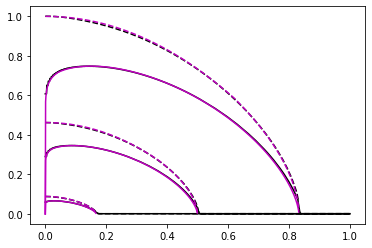

In [15]:
xheat = lambda t: 0.8332614*(t*10)
def test_1_Tr(x,t):
    ξ0 = 1.2746051
    ξ = ξ0*x/xheat(t)
    f = 1 - 0.75567*(ξ/ξ0)**2.0416
    f[ξ>ξ0*.75] = 1.2527*(1 - ξ[ξ>ξ0*.75]/ξ0)**0.55623
    return (t*10)**(86/57)*f
def test_1_T(x,t):
    ξ0 = 1.2746051
    ξ = ξ0*x/xheat(t)
    g = -0.15937*(ξ/ξ0)** 0.2194 + (ξ/ξ0)**0.074842 #ξ < 0.05ξ0

    g[ξ>ξ0*.05] = (0.63674 + 0.55611*(ξ[ξ>ξ0*.05]/ξ0)**0.56101)*(1 - ξ[ξ>ξ0*.05]/ξ0)**0.63964
    return (t*10)**(86/57)*g
#test_1_Tr = lambda x,t:((t*10)**(10/39)*(1-(x/xheat(t)))**(10/39))/10
#test_1_T = lambda x,t: test_1_Tr(x,t)
TBfunc = lambda t: 0.1*(1+0.0576603*(10*t)**(-8/13))**0.25*(10*t)**(tau)
phi_sol = Ts[-1]

for tval in (0.02,0.06,0.1):
    print(tval)
    tstep = np.argmin(np.abs(tval-ts))
    tval = ts[tstep]
    phi_sol = Ts[tstep]
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k-")
    np.savetxt("test1_inhomog_T_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    phi_sol = (phis[tstep]/ac)**.25
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k--")
    np.savetxt("test1_inhomog_Tr_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    plt.plot(xplot,(test_1_T(xplot,tval)),"m-")
    plt.plot(xplot,(test_1_Tr(xplot,tval)),"m--")
    np.savetxt("test1_inhomog_x.csv", xplot, delimiter=",")


In [16]:
#test 2
order = 3
I = 200
Lx = .35
hx = Lx/I

alpha = 2
alphap = 3
beta = 3
u0 = 0.01
k0 = 0.1
ks = 1e3
mu = 0.4
omega = -20/7
lam = 0.2
lamp = 0.1

xplot = np.linspace(0,Lx,1000)
x = np.linspace(hx/2,Lx-hx/2,I)
N = 8
MU, W = np.polynomial.legendre.leggauss(N)
q = np.zeros((I,N,order+1)) 
tau = 10/39
print(0.5*(tau*(alpha+beta-4)-1),-8/13)

@jit(float64[:,:](float64[:],float64),nopython=True,parallel=True)
def rho_full(x,omega):
    tmp = np.zeros((x.size,2))
    
    tmp[:,1] = x**-omega
    return tmp
rho = lambda tmp: rho_full(tmp,x,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True,parallel=True)
def eos_full(T,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return u0*(T)**beta*tmp_rho**(1-mu)
eos = lambda T: eos_full(T,x,u0,beta,mu,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def invEOS_full(E,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(E.shape)
    for col in range(E.shape[1]):
        tmp_rho[:,col] = x**-omega
    return (E/u0/ (tmp_rho**(1-mu)))**(1/beta)
invEOS = lambda E: invEOS_full(E,x,u0,beta,mu,omega)
Tinit = 1e-3
#print(eos(T),invEOS(eos(T)),T)
T = np.ones((I,order+1))*Tinit
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def sigma_func_nb(T,x,k0,alpha,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1) 
sigma_func = lambda T: sigma_func_nb(T,x,k0,alpha,lamp,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64,float64,float64),nopython=True)
def scat_func_nb(T,x,ks,alphap,alpha,lam,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return ks*(np.abs(T))**-alphap*tmp_rho**(lam+1)-k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1)
scat_func = lambda T: scat_func_nb(T,x,ks,alphap,alpha,lam,lamp,omega)
phi = ac*T**4
psi = np.zeros((I,N,order+1))+phi[:,None,:]
tfinal = 0.1
BCs = np.zeros((N,order+1)) #+q[0]/(sigma_t[0] - sigma_s[0])/2
@jit(float64[:,:](float64), nopython=True)
def BCFunc(t):
    out = np.zeros((N,order+1))
    tau = 5/2
    out[MU>0,:] = ac*((1 + 0.358968*(10*(t)+1e-18)**(tau))**.25 * (10*t)**6)**4
    out[MU<0,:] = ac*Tinit**4
    return out
phis,Ts,iterations,ts = temp_solve_dmd_inc(I,hx,q,sigma_func,scat_func,N,BCFunc, eos, invEOS, phi,psi, T,
               dt_min = 1e-6, dt_max = 0.001, tfinal = tfinal, order = order, LOUD=0, maxits=2000, fix=1, K=800);
#save
np.savez_compressed('Inhomog_test_2.npz', times_ns=ts*10, Tr_keV=(np.array(phis)/ac)**.25, T_keV=(Ts))

-0.3717948717948718 -0.6153846153846154
(200, 8, 4)
|t = 0.0000e+00, Current dt = 1.0000e-06, old dt = 1.0000e-06
t = 1.0000e-06, Current dt = 1.0000e-06, old dt = 1.0000e-06
0.0026173006604742963
t = 2.0000e-06, Current dt = 1.5000e-06, old dt = 1.0000e-06
0.0023731394546173123
t = 3.5000e-06, Current dt = 2.2500e-06, old dt = 1.5000e-06
0.0020252510387826924
t = 5.7500e-06, Current dt = 3.3750e-06, old dt = 2.2500e-06
0.0017766642609754958
t = 9.1250e-06, Current dt = 5.0625e-06, old dt = 3.3750e-06
0.0016513214040708366
t = 1.4187e-05, Current dt = 7.5937e-06, old dt = 5.0625e-06
0.0016407629809243422
t = 2.1781e-05, Current dt = 1.1391e-05, old dt = 7.5937e-06
0.001730275653051219
t = 3.3172e-05, Current dt = 1.7086e-05, old dt = 1.1391e-05
0.0019077185368228256
t = 5.0258e-05, Current dt = 2.5629e-05, old dt = 1.7086e-05
0.0021539016065738673
t = 7.5887e-05, Current dt = 3.8443e-05, old dt = 2.5629e-05
0.002481089391883055
t = 1.1433e-04, Current dt = 5.7665e-05, old dt = 3.8443e-

*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be to

*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be to

*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be to

0.00019580323141332864
t = 5.1770e-02, Current dt = 1.9580e-04, old dt = 1.7057e-04
0.00021638216636282783
t = 5.1966e-02, Current dt = 2.1638e-04, old dt = 1.9580e-04
0.0001629888592626226
t = 5.2182e-02, Current dt = 1.6299e-04, old dt = 2.1638e-04
0.00010744953879414287
t = 5.2345e-02, Current dt = 1.0745e-04, old dt = 1.6299e-04
0.00013545350692526612
t = 5.2452e-02, Current dt = 1.3545e-04, old dt = 1.0745e-04
0.0001750671280635644
t = 5.2588e-02, Current dt = 1.7507e-04, old dt = 1.3545e-04
0.0002011415388081056
t = 5.2763e-02, Current dt = 2.0114e-04, old dt = 1.7507e-04
0.00017744876022485388
t = 5.2964e-02, Current dt = 1.7745e-04, old dt = 2.0114e-04
0.00014109723258524248
t = 5.3141e-02, Current dt = 1.4110e-04, old dt = 1.7745e-04
0.00010449485793291748
t = 5.3283e-02, Current dt = 1.0449e-04, old dt = 1.4110e-04
0.00012156851088150594
t = 5.3387e-02, Current dt = 1.2157e-04, old dt = 1.0449e-04
0.00021017268862103525
t = 5.3509e-02, Current dt = 2.1017e-04, old dt = 1.2157

...

9.134769764793415e-05
t = 8.0322e-02, Current dt = 9.1348e-05, old dt = 7.2935e-05
*****Warning*****  The number of steps may be too small
8.616389526094876e-05
t = 8.0413e-02, Current dt = 8.6164e-05, old dt = 9.1348e-05
7.269096799033249e-05
t = 8.0500e-02, Current dt = 7.2691e-05, old dt = 8.6164e-05
7.622030646796786e-05
t = 8.0572e-02, Current dt = 7.6220e-05, old dt = 7.2691e-05
9.211337141839434e-05
t = 8.0648e-02, Current dt = 9.2113e-05, old dt = 7.6220e-05
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
8.26264197045964e-05
t = 8.0741e-02, Current dt = 8.2626e-05, old dt = 9.2113e-05
7.041455801281217e-05
t = 8.0823e-02, Current dt = 7.0415e-05, old dt = 8.2626e-05
7.046489455735867e-05
t = 8.0894e-02, Current dt = 7.0465e-05, old dt = 7.0415e-05
9.089540401830113e-05
t = 8.0964e-02, Current dt = 9.0895e-05, old dt = 7.0465e-05
8.417259396557133e-05
t = 8.10

7.082358961997702e-05
t = 8.5857e-02, Current dt = 7.0824e-05, old dt = 8.3491e-05
7.913732129285075e-05
t = 8.5928e-02, Current dt = 7.9137e-05, old dt = 7.0824e-05
8.772487814542201e-05
t = 8.6007e-02, Current dt = 8.7725e-05, old dt = 7.9137e-05
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
6.778458832883185e-05
t = 8.6095e-02, Current dt = 6.7785e-05, old dt = 8.7725e-05
8.521473357902923e-05
t = 8.6163e-02, Current dt = 8.5215e-05, old dt = 6.7785e-05
8.614024507881835e-05
t = 8.6248e-02, Current dt = 8.6140e-05, old dt = 8.5215e-05
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
8.230666675530274e-05
t = 8.6334e-02, Current dt = 8.2307e-05, old dt = 8.6140e-05
*****Warning*****  The numb

*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
6.7305409537302e-05
t = 8.9267e-02, Current dt = 6.7305e-05, old dt = 9.2750e-05
9.027413525222925e-05
t = 8.9334e-02, Current dt = 9.0274e-05, old dt = 6.7305e-05
8.1638612068732e-05
t = 8.9424e-02, Current dt = 8.1639e-05, old dt = 9.0274e-05
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
6.336365714731121e-05
t = 8.9506e-02, Current dt = 6.3364e-05, old dt = 8.1639e-05
8.281517099397127e-05
t = 8.9569e-02, Current dt = 8.2815e-05, old dt = 6.3364e-05
7.940238238867629e-05
t = 8.9652e-02, Current dt = 7.9402e-05, old dt = 8.2815e-05
**

*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
7.344453751406258e-05
t = 9.3964e-02, Current dt = 7.3445e-05, old dt = 7.0214e-05
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
7.127926783689639e-05
t = 9.4038e-02, Current dt = 7.1279e-05, old dt = 7.3445e-05
6.276924842903314e-05
t = 9.4109e-02, Current dt =

4.797573420932224e-05
t = 9.6934e-02, Current dt = 4.7976e-05, old dt = 4.8703e-05
*****Warning*****  The number of steps may be too small
8.622406699873828e-05
t = 9.6982e-02, Current dt = 8.6224e-05, old dt = 4.7976e-05
8.06324129201368e-05
t = 9.7068e-02, Current dt = 8.0632e-05, old dt = 8.6224e-05
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
7.671257537120326e-05
t = 9.7149e-02, Current dt = 7.6713e-05, old dt = 8.0632e-05
7.821175437831066e-05
t = 9.7225e-02, Current dt = 7.8212e-05, old dt = 7.6713e-05
6.50681546747299e-05
t = 9.7303e-02, Current dt = 6.5068e-05, old dt = 7.8212e-05
5.464370931146704e-05
t = 9.7369e-02, Current dt = 5.4644e-05, old dt = 6.5068e-05
9.285275162535316e-05
t = 9.7

0.0631385
0.0864201
1


/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  


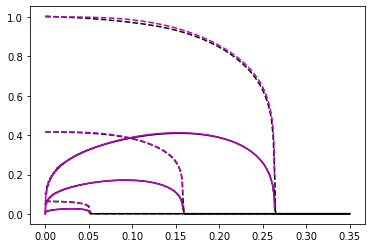

In [17]:
xheat = lambda t: 0.26348387*(t*10)**3.5
def test_1_Tr(x,t):
    ξ0 = 0.615503394
    ξ = ξ0*x/xheat(t)
    f = 1 - 0.35369*(ξ/ξ0)**3.2539
    f[ξ>ξ0*.75] = 1.1098*(1 - ξ[ξ>ξ0*.75]/ξ0)**0.1834
    return (t*10)**(6)*f
def test_1_T(x,t):
    ξ0 = 0.615503394
    ξ = ξ0*x/xheat(t)
    g = .52694*(ξ/ξ0)**0.28559 - (ξ/ξ0)**3.5311 #ξ < 0.05ξ0

    g[ξ>ξ0*.05] = (0.15073 + 0.55903*(ξ[ξ>ξ0*.05]/ξ0)**0.62589)*(1 - ξ[ξ>ξ0*.05]/ξ0)**0.32965
    return (t*10)**(6)*g
#test_1_Tr = lambda x,t:((t*10)**(10/39)*(1-(x/xheat(t)))**(10/39))/10
#test_1_T = lambda x,t: test_1_Tr(x,t)
TBfunc = lambda t: 0.1*(1+0.0576603*(10*t)**(-8/13))**0.25*(10*t)**(tau)
phi_sol = Ts[-1]

for tval in (0.0631385,.0864201,1):
    print(tval)
    tstep = np.argmin(np.abs(tval-ts))
    tval = ts[tstep]
    phi_sol = Ts[tstep]
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k-")
    np.savetxt("test2_inhomog_T_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    phi_sol = (phis[tstep]/ac)**.25
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k--")
    np.savetxt("test2_inhomog_Tr_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    plt.plot(xplot,(test_1_T(xplot,tval)),"m-")
    plt.plot(xplot,(test_1_Tr(xplot,tval)),"m--")
    np.savetxt("test2_inhomog_x.csv", xplot, delimiter=",")


In [70]:
#test 3
order = 3
I = 300
Lx = 1.1
hx = Lx/I

alpha = 4.5
alphap = 4.5
beta = 6
u0 = 0.01
k0 = 1e-3
ks = 2.
mu = 0.3
omega = 40/139
lam = 0.9
lamp = 0.9

xplot = np.linspace(0,Lx,1000)
x = np.linspace(hx/2,Lx-hx/2,I)
N = 8
MU, W = np.polynomial.legendre.leggauss(N)
q = np.zeros((I,N,order+1)) 


@jit(float64[:,:](float64[:],float64),nopython=True,parallel=True)
def rho_full(x,omega):
    tmp = np.zeros((x.size,2))
    
    tmp[:,1] = x**-omega
    return tmp
rho = lambda tmp: rho_full(tmp,x,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True,parallel=True)
def eos_full(T,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return u0*(np.abs(T))**beta*tmp_rho**(1-mu)
eos = lambda T: eos_full(T,x,u0,beta,mu,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def invEOS_full(E,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(E.shape)
    for col in range(E.shape[1]):
        tmp_rho[:,col] = x**-omega
    return (np.abs(E)/u0/ (tmp_rho**(1-mu)))**(1/beta)
invEOS = lambda E: invEOS_full(E,x,u0,beta,mu,omega)
Tinit = 5e-2
#print(eos(T),invEOS(eos(T)),T)
T = np.ones((I,order+1))*Tinit
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def sigma_func_nb(T,x,k0,alpha,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1) 
sigma_func = lambda T: sigma_func_nb(T,x,k0,alpha,lamp,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64,float64,float64),nopython=True)
def scat_func_nb(T,x,ks,alphap,alpha,lam,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return ks*(np.abs(T))**-alphap*tmp_rho**(lam+1)-k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1)
scat_func = lambda T: scat_func_nb(T,x,ks,alphap,alpha,lam,lamp,omega)
phi = ac*T**4
psi = np.zeros((I,N,order+1))+phi[:,None,:]
tfinal = 0.1
BCs = np.zeros((N,order+1)) #+q[0]/(sigma_t[0] - sigma_s[0])/2
@jit(float64[:,:](float64), nopython=True)
def BCFunc(t):
    out = np.zeros((N,order+1))
    tau = 14/139
    out[MU>0,:] = ac*((1.01008116*(10*(t)+1e-18)**(tau)))**4
    out[MU<0,:] = ac*Tinit**4
    return out
phis,Ts,iterations,ts = temp_solve_dmd_inc(I,hx,q,sigma_func,scat_func,N,BCFunc, eos, invEOS, phi,psi, T,
               dt_min = 1e-6, dt_max = 5e-5, tfinal = tfinal, order = order, LOUD=0, maxits=2000, fix=1, K=800);
#save
np.savez_compressed('Inhomog_test_3.npz', times_ns=ts*10, Tr_keV=(np.array(phis)/ac)**.25, T_keV=(Ts))

(300, 8, 4)
|t = 0.0000e+00, Current dt = 1.0000e-06, old dt = 1.0000e-06
t = 1.0000e-06, Current dt = 1.0000e-06, old dt = 1.0000e-06
2.2249065797602916e-06
t = 2.0000e-06, Current dt = 1.5000e-06, old dt = 1.0000e-06
1.5941934274540483e-06
t = 3.5000e-06, Current dt = 1.5942e-06, old dt = 1.5000e-06
3.852419938393885e-06
t = 5.0942e-06, Current dt = 2.3913e-06, old dt = 1.5942e-06
8.2470537540267e-06
t = 7.4855e-06, Current dt = 3.5869e-06, old dt = 2.3913e-06
1.0005581083490444e-05
t = 1.1072e-05, Current dt = 5.3804e-06, old dt = 3.5869e-06
1.3865943672686892e-05
t = 1.6453e-05, Current dt = 8.0706e-06, old dt = 5.3804e-06
1.9971130930384514e-05
t = 2.4523e-05, Current dt = 1.2106e-05, old dt = 8.0706e-06
7.524434309554984e-06
t = 3.6629e-05, Current dt = 7.5244e-06, old dt = 1.2106e-05
1.120900586620377e-05
t = 4.4154e-05, Current dt = 1.1209e-05, old dt = 7.5244e-06
1.2964776150233158e-05
t = 5.5363e-05, Current dt = 1.2965e-05, old dt = 1.1209e-05
1.887238534399199e-05
t = 6.832

5.66851205265018e-05
t = 4.0342e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
5.1203564745864044e-05
t = 4.0842e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
5.063103661321534e-05
t = 4.1342e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
6.324516928667271e-05
t = 4.1842e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
9.584973145512929e-05
t = 4.2342e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
5.2340392979637117e-05
t = 4.2842e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
5.431793359497934e-05
t = 4.3342e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
5.5477519993947096e-05
t = 4.3842e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
4.868715816754971e-05
t = 4.4342e-03, Current dt = 4.8

6.461141168729098e-05
t = 8.4327e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
*****Warning*****  The number of steps may be too small
5.647851276608972e-05
t = 8.4827e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
6.74518252223111e-05
t = 8.5327e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
*****Warning*****  The number of steps may be too small
0.00010735862401493289
t = 8.5827e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
6.170426842982851e-05
t = 8.6327e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
6.36443618184004e-05
t = 8.6827e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
5.433222164464125e-05
t = 8.7327e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
9.273246603645002e-05
t = 8.7827e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
*****Warning*****  The number of steps may be too small
5.964036655046547e-05
t = 8.8327e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
6.289782149801705e-05
t = 8.8827e-03, Current dt = 5.0000e-05, old dt = 5.0000e-05
7.4

6.464530109274242e-05
t = 1.3033e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
9.158989353265273e-05
t = 1.3083e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
6.546697249721202e-05
t = 1.3133e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
7.094302349843206e-05
t = 1.3183e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00010102824214047585
t = 1.3233e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00010724838683038082
t = 1.3283e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
6.486935981270137e-05
t = 1.3333e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
7.162936439432307e-05
t = 1.3383e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
6.455803389876792e-05
t = 1.3433e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
8.311469806020215e-05
t = 1.3483e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
6.441544857578444e-05
t = 1.3533e-02, Current dt = 5.000

7.329315682603362e-05
t = 1.7783e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
8.207100936947376e-05
t = 1.7833e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00010770468383547106
t = 1.7883e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00011543485783258507
t = 1.7933e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
7.383526100622465e-05
t = 1.7983e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
7.181757905961495e-05
t = 1.8033e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
8.356391707735065e-05
t = 1.8083e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
9.148467449698071e-05
t = 1.8133e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
7.217100541616354e-05
t = 1.8183e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
8.476300187625904e-05
t = 1.8233e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00015065039109708888
t = 1.8283e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
*****Warning*****  The number of steps may be too small
8.97728165929724e-05
t = 1.8

...

0.0002949309862791642
t = 8.0483e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00017986495765600418
t = 8.0533e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00016694940605206754
t = 8.0583e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00019507869476352848
t = 8.0633e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0003239864285049575
t = 8.0683e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0001799953478336367
t = 8.0733e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00015216690248875684
t = 8.0783e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00017358721691788326
t = 8.0833e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00027787353256711453
t = 8.0883e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00017695281752155766
t = 8.0933e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0001718386675882624
t = 8.0983e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00022072490670500955
t = 8.1033e-02, Current dt = 5.0000e-05, old dt = 5.0000e

0.0002826118977831331
t = 8.5333e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00015945976641569638
t = 8.5383e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00016520508192127453
t = 8.5433e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0001813111263953653
t = 8.5483e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0002123912496222885
t = 8.5533e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00016903819631472998
t = 8.5583e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00018689030333133086
t = 8.5633e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00028350747245983634
t = 8.5683e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00024601423146046084
t = 8.5733e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00015341180751667858
t = 8.5783e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00016844610516352686
t = 8.5833e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00021681703796292833
t = 8.5883e-02, Current dt = 5.0000e-05, old dt = 5.0000

0.0002526980294864122
t = 9.0133e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0001804799588434325
t = 9.0183e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.000184866277273164
t = 9.0233e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00025430576828438926
t = 9.0283e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00030125194279732344
t = 9.0333e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00016978579771973737
t = 9.0383e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00017141755670077116
t = 9.0433e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0001972727511549249
t = 9.0483e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0002223529839998324
t = 9.0533e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00017640061154414232
t = 9.0583e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0001861712124636027
t = 9.0633e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0002854504700891886
t = 9.0683e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05


0.000343219041495368
t = 9.4933e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00019882385127504648
t = 9.4983e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00016966794850791083
t = 9.5033e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00015386916003639863
t = 9.5083e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00026817811064381637
t = 9.5133e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00018663944375061568
t = 9.5183e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00019255712978976988
t = 9.5233e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0002661119655255987
t = 9.5283e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0003075841448175778
t = 9.5333e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00017679252341443356
t = 9.5383e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00017592778603448222
t = 9.5433e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00020349612498816687
t = 9.5483e-02, Current dt = 5.0000e-05, old dt = 5.0000e

0.00018465039783221592
t = 9.9833e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00020780731599739986
t = 9.9883e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.0003280614957103713
t = 9.9933e-02, Current dt = 5.0000e-05, old dt = 5.0000e-05
0.00023798093685952788
t = 9.9983e-02, Current dt = 1.7299e-05, old dt = 5.0000e-05
10

0.02
0.06
0.1


/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  


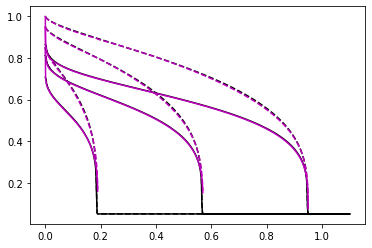

In [72]:
xheat = lambda t: 0.95029077*(t*10)
def test_1_Tr(x,t):
    ξ0 = 0.31411518
    ξ = ξ0*x/xheat(t)
    f = 1 - 0.31578*(ξ/ξ0)**0.66822
    f[ξ>ξ0*.2] = (0.95143 - 0.11368*(ξ[ξ>ξ0*.2]/ξ0)**1.4227)*(1-(ξ[ξ>ξ0*.2]/ξ0))**0.24206
    return (t*10)**(14/139)*f
def test_1_T(x,t):
    ξ0 = 0.31411518
    ξ = ξ0*x/xheat(t)
    g = 1+0.75349*(ξ/ξ0)**0.37109 - (ξ/ξ0)**0.24703 #ξ < 0.05ξ0

    g[ξ>ξ0*.05] = (1.2663 - 0.58658*(ξ[ξ>ξ0*.05]/ξ0)**0.061645)*(1 - ξ[ξ>ξ0*.05]/ξ0)**0.21797
    return (t*10)**(14/139)*g
#test_1_Tr = lambda x,t:((t*10)**(10/39)*(1-(x/xheat(t)))**(10/39))/10
#test_1_T = lambda x,t: test_1_Tr(x,t)
TBfunc = lambda t: 0.1*(1+0.0576603*(10*t)**(-8/13))**0.25*(10*t)**(tau)
phi_sol = Ts[-1]

for tval in (0.02,0.06,0.1):
    print(tval)
    tstep = np.argmin(np.abs(tval-ts))
    tval = ts[tstep]
    phi_sol = Ts[tstep]
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k-")
    np.savetxt("test3_inhomog_T_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    phi_sol = (phis[tstep]/ac)**.25
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k--")
    np.savetxt("test3_inhomog_Tr_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    plt.plot(xplot,(test_1_T(xplot,tval)),"m-")
    plt.plot(xplot,(test_1_Tr(xplot,tval)),"m--")
    np.savetxt("test3_inhomog_x.csv", xplot, delimiter=",")
    #plt.xlim(0.5,0.6)


In [14]:
#test 4
order = 3
I = 5000
Lx = 1.8
hx = Lx/I

alpha = 2
alphap = 3
beta = 6.5
u0 = 0.01
k0 = 1e-2
ks = 2.
mu = 0.4
omega = 4/7
lam = 0.2
lamp = 0.1

xplot = np.linspace(0,Lx,1000)
x = np.linspace(hx/2,Lx-hx/2,I)
N = 8
MU, W = np.polynomial.legendre.leggauss(N)
q = np.zeros((I,N,order+1)) 


@jit(float64[:,:](float64[:],float64),nopython=True,parallel=True)
def rho_full(x,omega):
    tmp = np.zeros((x.size,2))
    h = x[1]-x[0]
    xl = x-h/2
    xr = x+h/2
    tmp[:,1] = 1/h*((xr**(1-omega)) - (xl**(1-omega)))/(1-omega) #x**-omega
    return tmp
rho = lambda tmp: rho_full(tmp,x,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True,parallel=True)
def eos_full(T,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return np.sign(T)*u0*(np.abs(T))**beta*tmp_rho**(1-mu)
eos = lambda T: eos_full(T,x,u0,beta,mu,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def invEOS_full(E,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(E.shape)
    for col in range(E.shape[1]):
        tmp_rho[:,col] = x**-omega
    return np.sign(E)*(np.abs(E)/u0/ (tmp_rho**(1-mu)))**(1/beta)
invEOS = lambda E: invEOS_full(E,x,u0,beta,mu,omega)
Tinit = 1.0e-2
#print(eos(T),invEOS(eos(T)),T)
T = np.ones((I,order+1))*Tinit
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def sigma_func_nb(T,x,k0,alpha,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1) 
sigma_func = lambda T: sigma_func_nb(T,x,k0,alpha,lamp,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64,float64,float64),nopython=True)
def scat_func_nb(T,x,ks,alphap,alpha,lam,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return ks*(np.abs(T))**-alphap*tmp_rho**(lam+1)-k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1)
scat_func = lambda T: scat_func_nb(T,x,ks,alphap,alpha,lam,lamp,omega)
phi = ac*T**4
psi = np.zeros((I,N,order+1))+phi[:,None,:]
tfinal = 0.1
BCs = np.zeros((N,order+1)) #+q[0]/(sigma_t[0] - sigma_s[0])/2
@jit(float64[:,:](float64), nopython=True)
def BCFunc(t):
    out = np.zeros((N,order+1))
    tau = 17/158
    out[MU>0,:] = ac*((1 + 0.0590184*(10*(t)+1e-18)**(tau))**.25 * (10*t)**(12/79))**4
    out[MU<0,:] = ac*Tinit**4
    return out
phis,Ts,iterations,ts = temp_solve_dmd_inc(I,hx,q,sigma_func,scat_func,N,BCFunc, eos, invEOS, phi,psi, T,
               dt_min = 1e-6, dt_max = 1e-5, tfinal = tfinal, order = order, LOUD=0, maxits=2000, fix=1, K=800);
#save
np.savez_compressed('Inhomog_test_4_try.npz', times_ns=ts*10, Tr_keV=(np.array(phis)/ac)**.25, T_keV=(Ts))

(5000, 8, 4)
|t = 0.0000e+00, Current dt = 1.0000e-06, old dt = 1.0000e-06
t = 1.0000e-06, Current dt = 1.0000e-06, old dt = 1.0000e-06
3.3233258389127207e-06
t = 2.0000e-06, Current dt = 1.5000e-06, old dt = 1.0000e-06
2.0675669014001557e-06
t = 3.5000e-06, Current dt = 2.0676e-06, old dt = 1.5000e-06
3.612985230089975e-06
t = 5.5676e-06, Current dt = 3.6130e-06, old dt = 2.0676e-06
8.998757133046674e-06
t = 9.1806e-06, Current dt = 5.4195e-06, old dt = 3.6130e-06
1.102857482642892e-05
t = 1.4600e-05, Current dt = 1.0000e-05, old dt = 5.4195e-06
1.7349165991515996e-05
t = 2.4600e-05, Current dt = 1.0000e-05, old dt = 1.0000e-05
2.2224506776140044e-05
t = 3.4600e-05, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.6840094288175522e-05
t = 4.4600e-05, Current dt = 1.0000e-05, old dt = 1.0000e-05
2.2070680269722206e-05
t = 5.4600e-05, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.7884215967447153e-05
t = 6.4600e-05, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.7468319604258104e-05
t = 

1.2295906900363233e-05
t = 9.4460e-04, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.1483054415149368e-05
t = 9.5460e-04, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.4933602917087013e-05
t = 9.6460e-04, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.2550042970316063e-05
t = 9.7460e-04, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.2757610330588874e-05
t = 9.8460e-04, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.1640020368869227e-05
t = 9.9460e-04, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.4521681472602165e-05
t = 1.0046e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.3294907506297167e-05
t = 1.0146e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.1354376540003028e-05
t = 1.0246e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.7755548911987338e-05
t = 1.0346e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.2355122082476594e-05
t = 1.0446e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.1384656424497828e-05
t = 1.0546e-03, Current dt = 1.0000e-05, old dt = 1.0

1.3085950681897113e-05
t = 1.9246e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.4830967893437102e-05
t = 1.9346e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.3603772369056394e-05
t = 1.9446e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.3214493287179708e-05
t = 1.9546e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.4922926857635223e-05
t = 1.9646e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.3647757006309742e-05
t = 1.9746e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.3267848707792127e-05
t = 1.9846e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.492892100336685e-05
t = 1.9946e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.3532486634920259e-05
t = 2.0046e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.3277676931950012e-05
t = 2.0146e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.4764962965560256e-05
t = 2.0246e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.3250459967464308e-05
t = 2.0346e-03, Current dt = 1.0000e-05, old dt = 1.00

1.53324606145818e-05
t = 2.8846e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.358721971680338e-05
t = 2.8946e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.6914286166162934e-05
t = 2.9046e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.5420689913358035e-05
t = 2.9146e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.3928717872648685e-05
t = 2.9246e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.7441030062701553e-05
t = 2.9346e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.5693556449861202e-05
t = 2.9446e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.3879719387513915e-05
t = 2.9546e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.7084217544660086e-05
t = 2.9646e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.5019464598276005e-05
t = 2.9746e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.4931712656552126e-05
t = 2.9846e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.612341288264611e-05
t = 2.9946e-03, Current dt = 1.0000e-05, old dt = 1.0000e

1.8236005074004872e-05
t = 3.8446e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.680933772895109e-05
t = 3.8546e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.607238827222387e-05
t = 3.8646e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.7492412814420534e-05
t = 3.8746e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.5811967797219018e-05
t = 3.8846e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.7015592009033977e-05
t = 3.8946e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.7311503293402618e-05
t = 3.9046e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.438794155647716e-05
t = 3.9146e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.81855599352571e-05
t = 3.9246e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.662114381458056e-05
t = 3.9346e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.6272512715282092e-05
t = 3.9446e-03, Current dt = 1.0000e-05, old dt = 1.0000e-05
1.7584016895537483e-05
t = 3.9546e-03, Current dt = 1.0000e-05, old dt = 1.0000e-0

...

0.00010811511957988953
t = 9.5705e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00010953645474355442
t = 9.5715e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00010814497235318147
t = 9.5725e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00010936731272176228
t = 9.5735e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00010804208178151938
t = 9.5745e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.0001094386424415636
t = 9.5755e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00010755374169537659
t = 9.5765e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00010977988481927143
t = 9.5775e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00010711758605550145
t = 9.5785e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00010910541891006682
t = 9.5795e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00010735272561683516
t = 9.5805e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011027024215530828
t = 9.5815e-02, Current dt = 1.0000e-05, old dt = 1.00

0.0001123027166701176
t = 9.6685e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011019959595588613
t = 9.6695e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011132286039403726
t = 9.6705e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011040028540147027
t = 9.6715e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011153512866290795
t = 9.6725e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00010989371150823299
t = 9.6735e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011068206529781934
t = 9.6745e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011054429285293792
t = 9.6755e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011038555687165582
t = 9.6765e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.0001104269309842014
t = 9.6775e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011003906926388885
t = 9.6785e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.0001109030268961094
t = 9.6795e-02, Current dt = 1.0000e-05, old dt = 1.0000

0.00011503336561194635
t = 9.7665e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011096806824836632
t = 9.7675e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011405357958950706
t = 9.7685e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011171483330713118
t = 9.7695e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011354821279787549
t = 9.7705e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011164316278100106
t = 9.7715e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011417120553688874
t = 9.7725e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011131247567434588
t = 9.7735e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.0001139292068039964
t = 9.7745e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011109069195496874
t = 9.7755e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011342644721368523
t = 9.7765e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.0001109772912348678
t = 9.7775e-02, Current dt = 1.0000e-05, old dt = 1.000

0.00011574877130788203
t = 9.8645e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.0001115456733840595
t = 9.8655e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011580915465091828
t = 9.8665e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011169409777772249
t = 9.8675e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011502350777409866
t = 9.8685e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011216212026882665
t = 9.8695e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011478724141665899
t = 9.8705e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011249158864876635
t = 9.8715e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011512028448159408
t = 9.8725e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011218858231653541
t = 9.8735e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011487477997667767
t = 9.8745e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011195587220412244
t = 9.8755e-02, Current dt = 1.0000e-05, old dt = 1.00

0.00011665207117489587
t = 9.9625e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011251836516452414
t = 9.9635e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011586449238331584
t = 9.9645e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011302434631532851
t = 9.9655e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011559079294308596
t = 9.9665e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011329268869031005
t = 9.9675e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.000115893361060595
t = 9.9685e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011294979903707349
t = 9.9695e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011552022588867402
t = 9.9705e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011265725293334942
t = 9.9715e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011500670013042444
t = 9.9725e-02, Current dt = 1.0000e-05, old dt = 1.0000e-05
0.00011272955290065797
t = 9.9735e-02, Current dt = 1.0000e-05, old dt = 1.000

0.001
0.0233846
0.0630525
0.1


/var/folders/68/pdkq9t_j2gd7ksjtnf73t0vw0000gp/T/ipykernel_71772/3416698093.py:13: RuntimeWarning: invalid value encountered in power
  g[ξ>ξ0*.05] = (1.149 - 0.48665*(ξ[ξ>ξ0*.05]/ξ0)**0.11809)*(1 - ξ[ξ>ξ0*.05]/ξ0)**0.32793
/var/folders/68/pdkq9t_j2gd7ksjtnf73t0vw0000gp/T/ipykernel_71772/3416698093.py:6: RuntimeWarning: invalid value encountered in power
  f[ξ>ξ0*.2] = (0.93272 - 0.19194*(ξ[ξ>ξ0*.2]/ξ0)**0.56565)*(1-(ξ[ξ>ξ0*.2]/ξ0))**0.34578


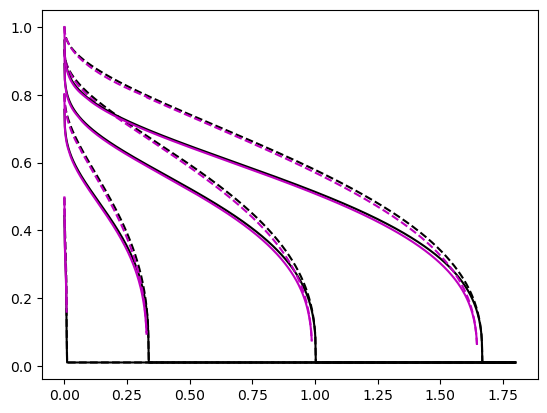

In [15]:
xheat = lambda t: 1.648216882*(t*10)**(175/158)
def test_1_Tr(x,t):
    ξ0 = 0.48463864
    ξ = ξ0*x/xheat(t)
    f = 1 - 0.44613*(ξ/ξ0)**0.47963
    f[ξ>ξ0*.2] = (0.93272 - 0.19194*(ξ[ξ>ξ0*.2]/ξ0)**0.56565)*(1-(ξ[ξ>ξ0*.2]/ξ0))**0.34578
    return (t*10)**(12/79)*f
def test_1_T(x,t):
    ξ0 = 0.48463864
    ξ = ξ0*x/xheat(t)
    g = 1+0.60577*(ξ/ξ0)**0.3164 - (ξ/ξ0)**0.27358 #ξ < 0.05ξ0

    g[ξ>ξ0*.05] = (1.149 - 0.48665*(ξ[ξ>ξ0*.05]/ξ0)**0.11809)*(1 - ξ[ξ>ξ0*.05]/ξ0)**0.32793
    return (t*10)**(12/79)*g
#test_1_Tr = lambda x,t:((t*10)**(10/39)*(1-(x/xheat(t)))**(10/39))/10
#test_1_T = lambda x,t: test_1_Tr(x,t)
TBfunc = lambda t: 0.1*(1+0.0576603*(10*t)**(-8/13))**0.25*(10*t)**(tau)
phi_sol = Ts[-1]

for tval in (0.001,0.0233846, 0.0630525,0.1):
    print(tval)
    tstep = np.argmin(np.abs(tval-ts))
    tval = ts[tstep]
    phi_sol = Ts[tstep]
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k-")
    np.savetxt("test4_inhomog_T_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    phi_sol = (phis[tstep]/ac)**.25
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k--")
    np.savetxt("test4_inhomog_Tr_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    plt.plot(xplot,(test_1_T(xplot,tval)),"m-")
    plt.plot(xplot,(test_1_Tr(xplot,tval)),"m--")
    np.savetxt("test4_inhomog_x.csv", xplot, delimiter=",")


In [60]:
#test 5
order = 3
I = 400
Lx = 1.
hx = Lx/I

alpha = 2
alphap = 3
beta = 5.5
u0 = 0.02
k0 = 5
ks = 5
mu = 0.2
omega = 60/161
lam = 0.35
lamp = 0.35

xplot = np.linspace(0,Lx,1000)
x = np.linspace(hx/2,Lx-hx/2,I)
N = 8
MU, W = np.polynomial.legendre.leggauss(N)
q = np.zeros((I,N,order+1)) 


@jit(float64[:,:](float64[:],float64),nopython=True,parallel=True)
def rho_full(x,omega):
    tmp = np.zeros((x.size,2))
    h = x[1]-x[0]
    xl = x-h/2
    xr = x+h/2
    tmp[:,1] = 1/h*((xr**(1-omega)) - (xl**(1-omega)))/(1-omega) #x**-omega
    return tmp
rho = lambda tmp: rho_full(tmp,x,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True,parallel=True)
def eos_full(T,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return u0*(np.abs(T))**beta*tmp_rho**(1-mu)
eos = lambda T: eos_full(T,x,u0,beta,mu,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def invEOS_full(E,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(E.shape)
    for col in range(E.shape[1]):
        tmp_rho[:,col] = x**-omega
    return (np.abs(E)/u0/ (tmp_rho**(1-mu)))**(1/beta)
invEOS = lambda E: invEOS_full(E,x,u0,beta,mu,omega)
Tinit = 1e-2
#print(eos(T),invEOS(eos(T)),T)
T = np.ones((I,order+1))*Tinit
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def sigma_func_nb(T,x,k0,alpha,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1) 
sigma_func = lambda T: sigma_func_nb(T,x,k0,alpha,lamp,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64,float64,float64),nopython=True)
def scat_func_nb(T,x,ks,alphap,alpha,lam,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return ks*(np.abs(T))**-alphap*tmp_rho**(lam+1)-k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1)
scat_func = lambda T: scat_func_nb(T,x,ks,alphap,alpha,lam,lamp,omega)
phi = ac*T**4
psi = np.zeros((I,N,order+1))+phi[:,None,:]
tfinal = 0.1
BCs = np.zeros((N,order+1)) #+q[0]/(sigma_t[0] - sigma_s[0])/2
@jit(float64[:,:](float64), nopython=True)
def BCFunc(t):
    out = np.zeros((N,order+1))
    tau = 16/145
    out[MU>0,:] = ac*((1 + 0.0890032*(10*(t)+1e-18)**(tau))**.25 * (10*t)**(32/145))**4
    out[MU<0,:] = ac*Tinit**4
    return out
phis,Ts,iterations,ts = temp_solve_dmd_inc(I,hx,q,sigma_func,scat_func,N,BCFunc, eos, invEOS, phi,psi, T,
               dt_min = 1e-6, dt_max = 1e-4, tfinal = tfinal, order = order, LOUD=0, maxits=2000, fix=1, K=800);
#save
np.savez_compressed('Inhomog_test_5.npz', times_ns=ts*10, Tr_keV=(np.array(phis)/ac)**.25, T_keV=(Ts))

(400, 8, 4)
|t = 0.0000e+00, Current dt = 1.0000e-06, old dt = 1.0000e-06
t = 1.0000e-06, Current dt = 1.0000e-06, old dt = 1.0000e-06
1.3524562150000082e-05
t = 2.0000e-06, Current dt = 1.5000e-06, old dt = 1.0000e-06
1.7666580408814096e-06
t = 3.5000e-06, Current dt = 1.7667e-06, old dt = 1.5000e-06
2.9189555304382724e-06
t = 5.2667e-06, Current dt = 2.9190e-06, old dt = 1.7667e-06
4.293508649506983e-06
t = 8.1856e-06, Current dt = 4.2935e-06, old dt = 2.9190e-06
7.081390082753877e-06
t = 1.2479e-05, Current dt = 7.0814e-06, old dt = 4.2935e-06
1.0096320843786909e-05
t = 1.9561e-05, Current dt = 1.0096e-05, old dt = 7.0814e-06
5.319618505979922e-06
t = 2.9657e-05, Current dt = 5.3196e-06, old dt = 1.0096e-05
1.1986632974082438e-05
t = 3.4976e-05, Current dt = 7.9794e-06, old dt = 5.3196e-06
5.4072665791423065e-06
t = 4.2956e-05, Current dt = 5.4073e-06, old dt = 7.9794e-06
4.699371873339446e-06
t = 4.8363e-05, Current dt = 4.6994e-06, old dt = 5.4073e-06
7.873458407978417e-06
t = 5.3

4.3023430160221304e-05
t = 3.6514e-03, Current dt = 4.3023e-05, old dt = 3.6906e-05
6.055727130144366e-05
t = 3.6944e-03, Current dt = 6.0557e-05, old dt = 4.3023e-05
6.076048042205193e-05
t = 3.7550e-03, Current dt = 6.0760e-05, old dt = 6.0557e-05
5.429548331176782e-05
t = 3.8157e-03, Current dt = 5.4295e-05, old dt = 6.0760e-05
4.4062041097315336e-05
t = 3.8700e-03, Current dt = 4.4062e-05, old dt = 5.4295e-05
3.4434547605441626e-05
t = 3.9141e-03, Current dt = 3.4435e-05, old dt = 4.4062e-05
4.032991526222026e-05
t = 3.9485e-03, Current dt = 4.0330e-05, old dt = 3.4435e-05
3.7401597244734845e-05
t = 3.9889e-03, Current dt = 3.7402e-05, old dt = 4.0330e-05
4.175868588450492e-05
t = 4.0263e-03, Current dt = 4.1759e-05, old dt = 3.7402e-05
6.150408327737433e-05
t = 4.0680e-03, Current dt = 6.1504e-05, old dt = 4.1759e-05
6.60853891427823e-05
t = 4.1295e-03, Current dt = 6.6085e-05, old dt = 6.1504e-05
5.7584205275022494e-05
t = 4.1956e-03, Current dt = 5.7584e-05, old dt = 6.6085e-05


6.153247962297664e-05
t = 8.8776e-03, Current dt = 6.1532e-05, old dt = 6.2915e-05
6.439098155018392e-05
t = 8.9392e-03, Current dt = 6.4391e-05, old dt = 6.1532e-05
5.605233645882617e-05
t = 9.0036e-03, Current dt = 5.6052e-05, old dt = 6.4391e-05
4.9939768624875265e-05
t = 9.0596e-03, Current dt = 4.9940e-05, old dt = 5.6052e-05
6.713356580702685e-05
t = 9.1095e-03, Current dt = 6.7134e-05, old dt = 4.9940e-05
6.395484570079419e-05
t = 9.1767e-03, Current dt = 6.3955e-05, old dt = 6.7134e-05
6.269931348536655e-05
t = 9.2406e-03, Current dt = 6.2699e-05, old dt = 6.3955e-05
6.274203474523648e-05
t = 9.3033e-03, Current dt = 6.2742e-05, old dt = 6.2699e-05
5.425140884572816e-05
t = 9.3661e-03, Current dt = 5.4251e-05, old dt = 6.2742e-05
5.026078507479593e-05
t = 9.4203e-03, Current dt = 5.0261e-05, old dt = 5.4251e-05
6.746707866040802e-05
t = 9.4706e-03, Current dt = 6.7467e-05, old dt = 5.0261e-05
6.545624167246896e-05
t = 9.5381e-03, Current dt = 6.5456e-05, old dt = 6.7467e-05
6.7

6.082009715916223e-05
t = 1.5669e-02, Current dt = 6.0820e-05, old dt = 7.1072e-05
8.223940040308323e-05
t = 1.5730e-02, Current dt = 8.2239e-05, old dt = 6.0820e-05
7.51776479329539e-05
t = 1.5812e-02, Current dt = 7.5178e-05, old dt = 8.2239e-05
7.819075011876242e-05
t = 1.5887e-02, Current dt = 7.8191e-05, old dt = 7.5178e-05
6.800822151986558e-05
t = 1.5965e-02, Current dt = 6.8008e-05, old dt = 7.8191e-05
8.66276394756365e-05
t = 1.6033e-02, Current dt = 8.6628e-05, old dt = 6.8008e-05
8.24129730275993e-05
t = 1.6120e-02, Current dt = 8.2413e-05, old dt = 8.6628e-05
8.943106829552506e-05
t = 1.6203e-02, Current dt = 8.9431e-05, old dt = 8.2413e-05
7.639918937474922e-05
t = 1.6292e-02, Current dt = 7.6399e-05, old dt = 8.9431e-05
7.102269827303164e-05
t = 1.6368e-02, Current dt = 7.1023e-05, old dt = 7.6399e-05
8.271974899304434e-05
t = 1.6439e-02, Current dt = 8.2720e-05, old dt = 7.1023e-05
8.085539106394838e-05
t = 1.6522e-02, Current dt = 8.0855e-05, old dt = 8.2720e-05
7.44666

0.0001054119842892736
t = 2.4183e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
8.798467282822753e-05
t = 2.4283e-02, Current dt = 8.7985e-05, old dt = 1.0000e-04
0.00010262407555656618
t = 2.4371e-02, Current dt = 1.0000e-04, old dt = 8.7985e-05
9.45817812511501e-05
t = 2.4471e-02, Current dt = 9.4582e-05, old dt = 1.0000e-04
*****Warning*****  The number of steps may be too small
9.153959575241609e-05
t = 2.4566e-02, Current dt = 9.1540e-05, old dt = 9.4582e-05
8.686927138790864e-05
t = 2.4657e-02, Current dt = 8.6869e-05, old dt = 9.1540e-05
0.00010107045242008823
t = 2.4744e-02, Current dt = 1.0000e-04, old dt = 8.6869e-05
0.00010822779848633969
t = 2.4844e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
8.807592126022875e-05
t = 2.4944e-02, Current dt = 8.8076e-05, old dt = 1.0000e-04
0.0001090823366588558
t = 2.5032e-02, Current dt = 1.0000e-04, old dt = 8.8076e-05
9.561564123028434e-05
t = 2.5132e-02, Current dt = 9.5616e-05, old dt = 1.0000e-04
8.988208350006724e-05
t = 2.5

...

*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
0.00012680058883980742
t = 6.0798e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.000178313134269032
t = 6.0898e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0001559832234128426
t = 6.0998e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0001460034687843917
t = 6.1098e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00016069875044100748
t = 6.1198e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0001463328108590558
t 

0.00017092967489988528
t = 6.9598e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00015033805703888669
t = 6.9698e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00019314661739781947
t = 6.9798e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00017669453041795828
t = 6.9898e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
0.00014193696890663456
t = 6.9998e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
70.00016574656326869442
t = 7.0098e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00015651578112346629
t = 7.0198e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00017322160831943865
t = 7.0298e-02, Current dt = 1.0000e-04, old dt = 1.

0.00017735071660489958
t = 7.8998e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00018406587597047876
t = 7.9098e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0001888661043310661
t = 7.9198e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00017173923204146868
t = 7.9298e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0002027166062498672
t = 7.9398e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00019118568846510276
t = 7.9498e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00015901186774215184
t = 7.9598e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00020985097378804657
t = 7.9698e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00019338554779641152
t = 7.9798e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0001796710204427502
t = 7.9898e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00019184531123715972
t = 7.9998e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
80.00017738277264274662
t = 8.0098e-02, Current dt = 1.0000e-04, old dt = 1.000

0.00020714872806940104
t = 8.8798e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00019497222643376932
t = 8.8898e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00020294084967399932
t = 8.8998e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00018749066249129875
t = 8.9098e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0002140787294835281
t = 8.9198e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00020307134670220122
t = 8.9298e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0001719222898650098
t = 8.9398e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00022617118408532302
t = 8.9498e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00020937516492835657
t = 8.9598e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00019031066404574722
t = 8.9698e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00020562587569552951
t = 8.9798e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00018861949670680343
t = 8.9898e-02, Current dt = 1.0000e-04, old dt = 1.000

0.0002375371835054298
t = 9.8598e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00021486039630136083
t = 9.8698e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00021469370495894456
t = 9.8798e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00021863867470034738
t = 9.8898e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00019408044400193766
t = 9.8998e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00023851997460070957
t = 9.9098e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0002245646601183306
t = 9.9198e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00019400314295193267
t = 9.9298e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.00024060046387426189
t = 9.9398e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0002182959547561673
t = 9.9498e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0002166282574539282
t = 9.9598e-02, Current dt = 1.0000e-04, old dt = 1.0000e-04
0.0002208045332610162
t = 9.9698e-02, Current dt = 1.0000e-04, old dt = 1.0000e-

0.02346891
0.063124555
0.1


/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  


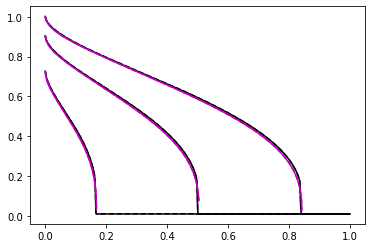

In [61]:
xheat = lambda t: 0.8428997*(t*10)**(161/145)
def test_1_Tr(x,t):
    ξ0 = 0.53073002
    ξ = ξ0*x/xheat(t)
    f = 1 - 0.43238 *(ξ/ξ0)**0.55116
    f[ξ>ξ0*.1] = (0.97888 - 0.23325*(ξ[ξ>ξ0*.1]/ξ0)**0.53204)*(1-(ξ[ξ>ξ0*.1]/ξ0))**0.34725
    return (t*10)**(32/145)*f
def test_1_T(x,t):
    ξ0 = 0.53073002
    ξ = ξ0*x/xheat(t)
    g = 1 - 0.43238 *(ξ/ξ0)**0.55116

    g[ξ>ξ0*.1] = (0.97888 - 0.23325*(ξ[ξ>ξ0*.1]/ξ0)**0.53204)*(1-(ξ[ξ>ξ0*.1]/ξ0))**0.34725
    return (t*10)**(32/145)*g
#test_1_Tr = lambda x,t:((t*10)**(10/39)*(1-(x/xheat(t)))**(10/39))/10
#test_1_T = lambda x,t: test_1_Tr(x,t)
TBfunc = lambda t: 0.1*(1+0.0576603*(10*t)**(-8/13))**0.25*(10*t)**(tau)
phi_sol = Ts[-1]

for tval in (0.02346891, 0.063124555,0.1):
    print(tval)
    tstep = np.argmin(np.abs(tval-ts))
    tval = ts[tstep]
    phi_sol = Ts[tstep]
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k-")
    np.savetxt("test5_inhomog_T_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    phi_sol = (phis[tstep]/ac)**.25
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k--")
    np.savetxt("test5_inhomog_Tr_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    plt.plot(xplot,(test_1_T(xplot,tval)),"m-")
    plt.plot(xplot,(test_1_Tr(xplot,tval)),"m--")
    np.savetxt("test5_inhomog_x.csv", xplot, delimiter=",")


In [24]:
#test 6
order = 3
I = 200
Lx = 1.0
hx = Lx/I

alpha = 3.5
alphap = 3.5
beta = 2.5
u0 = 0.01
k0 = 100
ks = 2000
mu = 0
omega = -3
lam = 1
lamp = 1

xplot = np.linspace(0,Lx,1000)
x = np.linspace(hx/2,Lx-hx/2,I)
N = 8
MU, W = np.polynomial.legendre.leggauss(N)
q = np.zeros((I,N,order+1)) 


@jit(float64[:,:](float64[:],float64),nopython=True,parallel=True)
def rho_full(x,omega):
    tmp = np.zeros((x.size,2))
    
    tmp[:,1] = x**-omega
    return tmp
rho = lambda tmp: rho_full(tmp,x,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True,parallel=True)
def eos_full(T,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return u0*(np.abs(T))**beta*tmp_rho**(1-mu)
eos = lambda T: eos_full(T,x,u0,beta,mu,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def invEOS_full(E,x,u0,beta,mu,omega):
    tmp_rho = np.zeros(E.shape)
    for col in range(E.shape[1]):
        tmp_rho[:,col] = x**-omega
    return (np.abs(E)/u0/ (tmp_rho**(1-mu)))**(1/beta)
invEOS = lambda E: invEOS_full(E,x,u0,beta,mu,omega)
Tinit = 1e-2
#print(eos(T),invEOS(eos(T)),T)
T = np.ones((I,order+1))*Tinit
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64),nopython=True)
def sigma_func_nb(T,x,k0,alpha,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1) 
sigma_func = lambda T: sigma_func_nb(T,x,k0,alpha,lamp,omega)
@jit(float64[:,:](float64[:,:],float64[:],float64,float64,float64,float64,float64,float64),nopython=True)
def scat_func_nb(T,x,ks,alphap,alpha,lam,lamp,omega):
    tmp_rho = np.zeros(T.shape)
    for col in range(T.shape[1]):
        tmp_rho[:,col] = x**-omega
    return ks*(np.abs(T))**-alphap*tmp_rho**(lam+1)-k0*(np.abs(T))**-alpha*tmp_rho**(lamp+1)
scat_func = lambda T: scat_func_nb(T,x,ks,alphap,alpha,lam,lamp,omega)
phi = ac*T**4
psi = np.zeros((I,N,order+1))+phi[:,None,:]
tfinal = 0.1
BCs = np.zeros((N,order+1)) #+q[0]/(sigma_t[0] - sigma_s[0])/2
@jit(float64[:,:](float64), nopython=True)
def BCFunc(t):
    out = np.zeros((N,order+1))
    tau = 2
    out[MU>0,:] = ac*((1.0719423*(10*(t)+1e-18)**(tau)))**4
    out[MU<0,:] = ac*Tinit**4
    return out
phis,Ts,iterations,ts = temp_solve_dmd_inc(I,hx,q,sigma_func,scat_func,N,BCFunc, eos, invEOS, phi,psi, T,
               dt_min = 1e-6, dt_max = 1e-3, tfinal = tfinal, order = order, LOUD=0, maxits=2000, fix=1, K=800);
#save
np.savez_compressed('Inhomog_test_6.npz', times_ns=ts*10, Tr_keV=(np.array(phis)/ac)**.25, T_keV=(Ts))

(200, 8, 4)
|t = 0.0000e+00, Current dt = 1.0000e-06, old dt = 1.0000e-06
t = 1.0000e-06, Current dt = 1.0000e-06, old dt = 1.0000e-06
0.002130699057942204
t = 2.0000e-06, Current dt = 1.5000e-06, old dt = 1.0000e-06
0.001933098231313311
t = 3.5000e-06, Current dt = 2.2500e-06, old dt = 1.5000e-06
0.0015959833216926055
t = 5.7500e-06, Current dt = 3.3750e-06, old dt = 2.2500e-06
0.001157410274659819
t = 9.1250e-06, Current dt = 5.0625e-06, old dt = 3.3750e-06
0.0007517664589808566
t = 1.4187e-05, Current dt = 7.5937e-06, old dt = 5.0625e-06
0.00048152681467878675
t = 2.1781e-05, Current dt = 1.1391e-05, old dt = 7.5937e-06
0.00030031053665677325
t = 3.3172e-05, Current dt = 1.7086e-05, old dt = 1.1391e-05
0.00018669083518358203
t = 5.0258e-05, Current dt = 2.5629e-05, old dt = 1.7086e-05
0.00012597602610926942
t = 7.5887e-05, Current dt = 3.8443e-05, old dt = 2.5629e-05
0.00010122486693509971
t = 1.1433e-04, Current dt = 5.7665e-05, old dt = 3.8443e-05
0.00010340516326470543
t = 1.7200

0.00013880795545737344
t = 2.7990e-02, Current dt = 1.3881e-04, old dt = 1.4313e-04
0.00021771287954056864
t = 2.8129e-02, Current dt = 2.1771e-04, old dt = 1.3881e-04
0.0001984348229170087
t = 2.8346e-02, Current dt = 1.9843e-04, old dt = 2.1771e-04
0.00012199877874946928
t = 2.8545e-02, Current dt = 1.2200e-04, old dt = 1.9843e-04
0.0001200357953206146
t = 2.8667e-02, Current dt = 1.2004e-04, old dt = 1.2200e-04
0.00016936422470251926
t = 2.8787e-02, Current dt = 1.6936e-04, old dt = 1.2004e-04
0.00023882129817700805
t = 2.8956e-02, Current dt = 2.3882e-04, old dt = 1.6936e-04
0.0001966757405118361
t = 2.9195e-02, Current dt = 1.9668e-04, old dt = 2.3882e-04
0.0001146226743648224
t = 2.9392e-02, Current dt = 1.1462e-04, old dt = 1.9668e-04
0.00010126297822454463
t = 2.9506e-02, Current dt = 1.0126e-04, old dt = 1.1462e-04
0.00015820267372692684
t = 2.9607e-02, Current dt = 1.5820e-04, old dt = 1.0126e-04
0.00022345467354484855
t = 2.9766e-02, Current dt = 2.2345e-04, old dt = 1.5820e

0.00012167592747949243
t = 4.3287e-02, Current dt = 1.2168e-04, old dt = 1.4918e-04
0.00010218733942611775
t = 4.3409e-02, Current dt = 1.0219e-04, old dt = 1.2168e-04
0.00015999524784724402
t = 4.3511e-02, Current dt = 1.6000e-04, old dt = 1.0219e-04
0.00018611104835141302
t = 4.3671e-02, Current dt = 1.8611e-04, old dt = 1.6000e-04
0.00015468101562654755
t = 4.3857e-02, Current dt = 1.5468e-04, old dt = 1.8611e-04
0.00011489017164439238
t = 4.4012e-02, Current dt = 1.1489e-04, old dt = 1.5468e-04
0.00011674114976069088
t = 4.4126e-02, Current dt = 1.1674e-04, old dt = 1.1489e-04
0.0001421728448076957
t = 4.4243e-02, Current dt = 1.4217e-04, old dt = 1.1674e-04
0.0001998073168800656
t = 4.4385e-02, Current dt = 1.9981e-04, old dt = 1.4217e-04
0.00020381461840473304
t = 4.4585e-02, Current dt = 2.0381e-04, old dt = 1.9981e-04
0.00014182369917527574
t = 4.4789e-02, Current dt = 1.4182e-04, old dt = 2.0381e-04
0.00012399934692708124
t = 4.4931e-02, Current dt = 1.2400e-04, old dt = 1.418

0.00020551700983450225
t = 5.7722e-02, Current dt = 2.0552e-04, old dt = 2.1154e-04
0.0001544618793169898
t = 5.7928e-02, Current dt = 1.5446e-04, old dt = 2.0552e-04
0.00014705324329456542
t = 5.8082e-02, Current dt = 1.4705e-04, old dt = 1.5446e-04
0.00012161744858536778
t = 5.8229e-02, Current dt = 1.2162e-04, old dt = 1.4705e-04
0.00018173590258584762
t = 5.8351e-02, Current dt = 1.8174e-04, old dt = 1.2162e-04
0.00017482688699461003
t = 5.8533e-02, Current dt = 1.7483e-04, old dt = 1.8174e-04
0.00014785481663829905
t = 5.8708e-02, Current dt = 1.4785e-04, old dt = 1.7483e-04
0.000128063349029487
t = 5.8855e-02, Current dt = 1.2806e-04, old dt = 1.4785e-04
0.0001049489436220258
t = 5.8983e-02, Current dt = 1.0495e-04, old dt = 1.2806e-04
0.0001260451135102876
t = 5.9088e-02, Current dt = 1.2605e-04, old dt = 1.0495e-04
0.00014244900156300507
t = 5.9214e-02, Current dt = 1.4245e-04, old dt = 1.2605e-04
0.00015422161995646175
t = 5.9357e-02, Current dt = 1.5422e-04, old dt = 1.4245e-

0.0001370081866164795
t = 7.3094e-02, Current dt = 1.3701e-04, old dt = 1.7211e-04
0.00016541889236599633
t = 7.3231e-02, Current dt = 1.6542e-04, old dt = 1.3701e-04
*****Warning*****  The number of steps may be too small
*****Warning*****  The number of steps may be too small
0.0001408656877128142
t = 7.3397e-02, Current dt = 1.4087e-04, old dt = 1.6542e-04
0.00013409891291922953
t = 7.3538e-02, Current dt = 1.3410e-04, old dt = 1.4087e-04
0.00016740857388698754
t = 7.3672e-02, Current dt = 1.6741e-04, old dt = 1.3410e-04
0.00014784253235833919
t = 7.3839e-02, Current dt = 1.4784e-04, old dt = 1.6741e-04
0.00018715150527912744
t = 7.3987e-02, Current dt = 1.8715e-04, old dt = 1.4784e-04
0.0001864311567806755
t = 7.4174e-02, Current dt = 1.8643e-04, old dt = 1.8715e-04
0.0001732896502591097
t = 7.4361e-02, Current dt = 1.7329e-04, old dt = 1.8643e-04
0.00015330776544850307
t = 7.4534e-02, Current dt = 1.5331e-04, old dt = 1.7329e-04
0.00012267264181479008
t = 7.4687e-02, Current dt = 

0.00015907676318000847
t = 8.7607e-02, Current dt = 1.5908e-04, old dt = 1.6647e-04
0.0001880740418072448
t = 8.7766e-02, Current dt = 1.8807e-04, old dt = 1.5908e-04
0.00016266988479848976
t = 8.7954e-02, Current dt = 1.6267e-04, old dt = 1.8807e-04
0.0001856096053563541
t = 8.8116e-02, Current dt = 1.8561e-04, old dt = 1.6267e-04
0.00015097438062343743
t = 8.8302e-02, Current dt = 1.5097e-04, old dt = 1.8561e-04
0.00013317789795654026
t = 8.8453e-02, Current dt = 1.3318e-04, old dt = 1.5097e-04
0.00015263930582986576
t = 8.8586e-02, Current dt = 1.5264e-04, old dt = 1.3318e-04
0.0001676832415222923
t = 8.8739e-02, Current dt = 1.6768e-04, old dt = 1.5264e-04
0.00020322482633184497
t = 8.8907e-02, Current dt = 2.0322e-04, old dt = 1.6768e-04
0.00016865982247157968
t = 8.9110e-02, Current dt = 1.6866e-04, old dt = 2.0322e-04
0.0001421536336233034
t = 8.9278e-02, Current dt = 1.4215e-04, old dt = 1.6866e-04
0.00014605412177145328
t = 8.9421e-02, Current dt = 1.4605e-04, old dt = 1.4215e

0.02
0.06
0.1


/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in power
  del sys.path[0]
/Users/rmcclarr/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in power
  


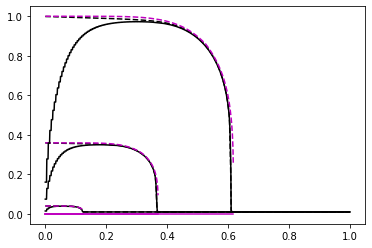

In [25]:
xheat = lambda t: 0.61806779*(t*10)
def test_1_Tr(x,t):
    ξ0 = 1.19867771
    ξ = ξ0*x/xheat(t)
    f = 1 - 0.38037  *(ξ/ξ0)**6.1993
    f[ξ>ξ0*.85] = (1.2945 - 0.089492*(ξ[ξ>ξ0*.85]/ξ0)**53.199)*(1-(ξ[ξ>ξ0*.85]/ξ0))**0.21389
    return (t*10)**(2)*f
def test_1_T(x,t):
    ξ0 = 1.19867771
    ξ = ξ0*x/xheat(t)
    g = 1 - 0.43238 *(ξ/ξ0)**0.55116

    g[ξ>ξ0*.1] = (0.97888 - 0.23325*(ξ[ξ>ξ0*.1]/ξ0)**0.53204)*(1-(ξ[ξ>ξ0*.1]/ξ0))**0.34725
    return 0*(t*10)**(2)*g
#test_1_Tr = lambda x,t:((t*10)**(10/39)*(1-(x/xheat(t)))**(10/39))/10
#test_1_T = lambda x,t: test_1_Tr(x,t)
TBfunc = lambda t: 0.1*(1+0.0576603*(10*t)**(-8/13))**0.25*(10*t)**(tau)
phi_sol = Ts[-1]

for tval in (0.02, 0.06,0.1):
    print(tval)
    tstep = np.argmin(np.abs(tval-ts))
    tval = ts[tstep]
    phi_sol = Ts[tstep]
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k-")
    np.savetxt("test6_inhomog_T_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    phi_sol = (phis[tstep]/ac)**.25
    plt.plot(xplot,BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot),"k--")
    np.savetxt("test6_inhomog_Tr_%0.2fns.csv" % (tval*10), BPoly(phi_sol.transpose(),np.linspace(0,Lx,I+1))(xplot), delimiter=",")
    plt.plot(xplot,(test_1_T(xplot,tval)),"m-")
    plt.plot(xplot,(test_1_Tr(xplot,tval)),"m--")
    np.savetxt("test6_inhomog_x.csv", xplot, delimiter=",")


In [26]:
tmp = lambda t: (0.1*(1+0.0576603*(10*t)**(-8/13))*(10*t)**(10/39))
tmp(0.1)

0.10576603000000001

In [27]:
n=4
print(MU[n],MU[n-N//2])

0.18343464249564978 -0.9602898564975362


In [28]:
MU

array([-0.96028986, -0.79666648, -0.52553241, -0.18343464,  0.18343464,
        0.52553241,  0.79666648,  0.96028986])

In [29]:
print("%0.7e" %(MU[0]))

-9.6028986e-01
